### PRIDAT CORELACIE V EDA


In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import arff
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    recall_score,
    precision_recall_curve,
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import wandb


In [2]:
config = {
    'experiment_name': 'mlp_weighted_baseline',
    'batch_size_train': 64,
    'batch_size_test': 256,
    'epochs': 80,
    'use_early_stopping': False,
    'early_stopping_patience': 10,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'hidden_dims': [128,64],
    'dropout_rate': 0.0,
    'use_batch_norm': False,
    'use_skip_connection': False,
    'loss_type': 'bce',
    'focal_gamma': 2.0,
    'threshold': 0.5,
}


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [4]:
DATA_PATH = Path('dataset_31_credit-g.arff')
raw_data, meta = arff.loadarff(DATA_PATH)
df = pd.DataFrame(raw_data)



df.head()




,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,b'<0',6.0,b'critical/other existing credit',b'radio/tv',1169.0,b'no known savings',b'>=7',4.0,b'male single',b'none',...,b'real estate',67.0,b'none',b'own',2.0,b'skilled',1.0,b'yes',b'yes',b'good'
1,b'0<=X<200',48.0,b'existing paid',b'radio/tv',5951.0,b'<100',b'1<=X<4',2.0,b'female div/dep/mar',b'none',...,b'real estate',22.0,b'none',b'own',1.0,b'skilled',1.0,b'none',b'yes',b'bad'
2,b'no checking',12.0,b'critical/other existing credit',b'education',2096.0,b'<100',b'4<=X<7',2.0,b'male single',b'none',...,b'real estate',49.0,b'none',b'own',1.0,b'unskilled resident',2.0,b'none',b'yes',b'good'
3,b'<0',42.0,b'existing paid',b'furniture/equipment',7882.0,b'<100',b'4<=X<7',2.0,b'male single',b'guarantor',...,b'life insurance',45.0,b'none',b'for free',1.0,b'skilled',2.0,b'none',b'yes',b'good'
4,b'<0',24.0,b'delayed previously',b'new car',4870.0,b'<100',b'1<=X<4',3.0,b'male single',b'none',...,b'no known property',53.0,b'none',b'for free',2.0,b'skilled',2.0,b'none',b'yes',b'bad'


In [5]:
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].apply(lambda x: x.decode() if isinstance(x, (bytes, bytearray)) else x)

df['target'] = (df['class'] == 'bad').astype(int)

df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class,target
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,67.0,none,own,2.0,skilled,1.0,yes,yes,good,0
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,22.0,none,own,1.0,skilled,1.0,none,yes,bad,1
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good,0
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,45.0,none,for free,1.0,skilled,2.0,none,yes,good,0
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,53.0,none,for free,2.0,skilled,2.0,none,yes,bad,1


**Poznamka:** Tu dekodujeme kategoricke hodnoty z `bytes` na `str` a vytvarame cielovu premennu `target`. Trieda `bad` je mapovana na `1`, teda pozitivna trieda, ktoru sa snazime zachytit.


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   checking_status         1000 non-null   str    
 1   duration                1000 non-null   float64
 2   credit_history          1000 non-null   str    
 3   purpose                 1000 non-null   str    
 4   credit_amount           1000 non-null   float64
 5   savings_status          1000 non-null   str    
 6   employment              1000 non-null   str    
 7   installment_commitment  1000 non-null   float64
 8   personal_status         1000 non-null   str    
 9   other_parties           1000 non-null   str    
 10  residence_since         1000 non-null   float64
 11  property_magnitude      1000 non-null   str    
 12  age                     1000 non-null   float64
 13  other_payment_plans     1000 non-null   str    
 14  housing                 1000 non-null   str    
 15 

In [7]:

missing = df.isna().sum().sort_values(ascending=False)
class_counts = df['class'].value_counts()

print('Total missing values:', int(missing.sum()))
print('Class balance:')
print(class_counts)
print('Class proportions:')
print((class_counts / len(df)).round(3))


Total missing values: 0
Class balance:
class
good    700
bad     300
Name: count, dtype: int64
Class proportions:
class
good    0.7
bad     0.3
Name: count, dtype: float64


**Poznamka:** Overujeme kvalitu datasetu a rozdelenie tried. Vidime, ze data nemaju chybajuce hodnoty a triedy su nevyvazene (`good` 70 %, `bad` 30 %), co je dolezite pre volbu metrik a treningovej strategie.


In [8]:

num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != 'target']
cat_cols = [c for c in df.columns if c not in num_cols + ['class', 'target']]

print('Numeric columns:', num_cols)
print('Categorical columns:', cat_cols)
print('Numeric summary:')
display(df[num_cols].describe().T)


Numeric columns: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Categorical columns: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']
Numeric summary:


,count,mean,std,min,25%,50%,75%,max
duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
installment_commitment,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
residence_since,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
existing_credits,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
num_dependents,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


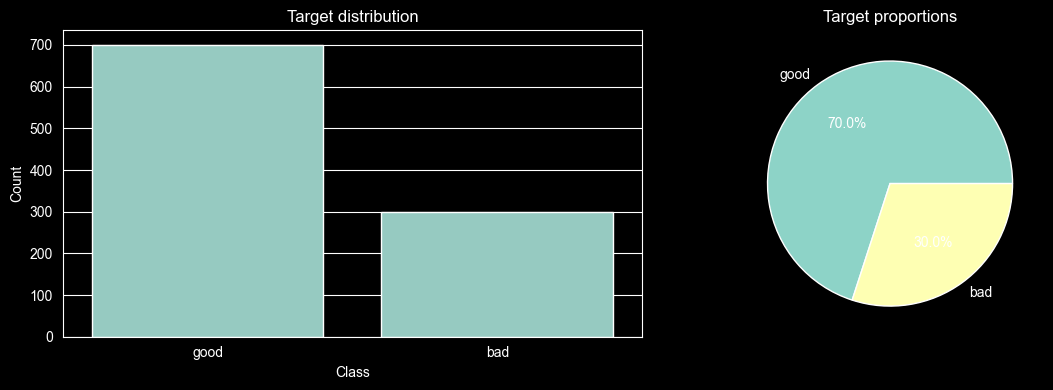

In [9]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='class', ax=axes[0])
axes[0].set_title('Target distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

class_counts.plot.pie(autopct='%1.1f%%', ax=axes[1])
axes[1].set_ylabel('')
axes[1].set_title('Target proportions')

plt.tight_layout()
plt.show()


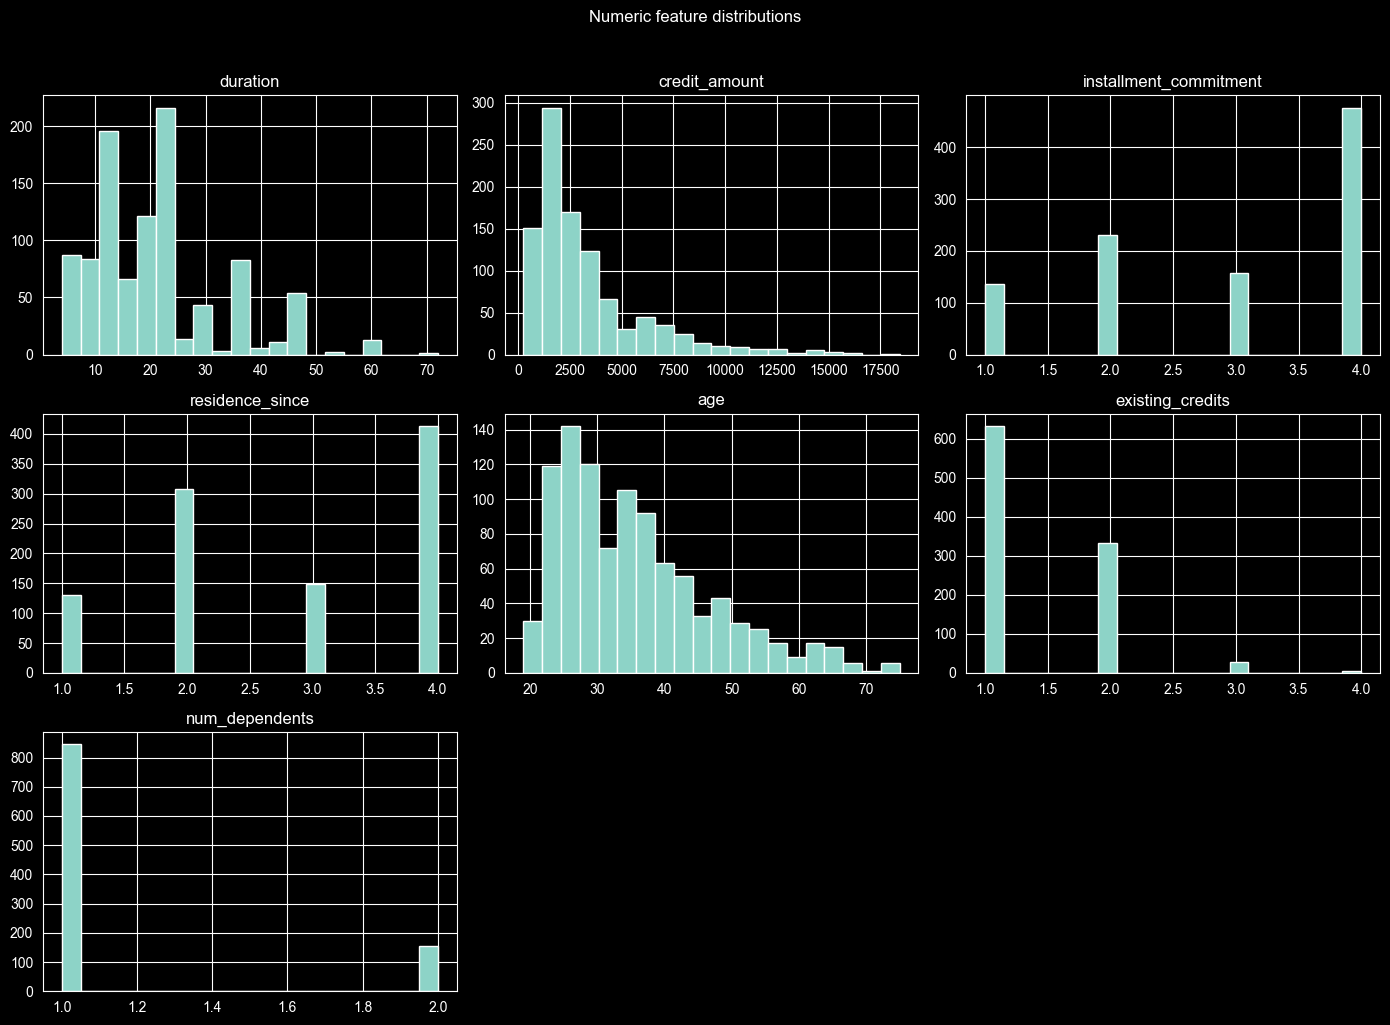

In [10]:

_ = df[num_cols].hist(figsize=(14, 10), bins=20)
plt.suptitle('Numeric feature distributions', y=1.02)
plt.tight_layout()
plt.show()


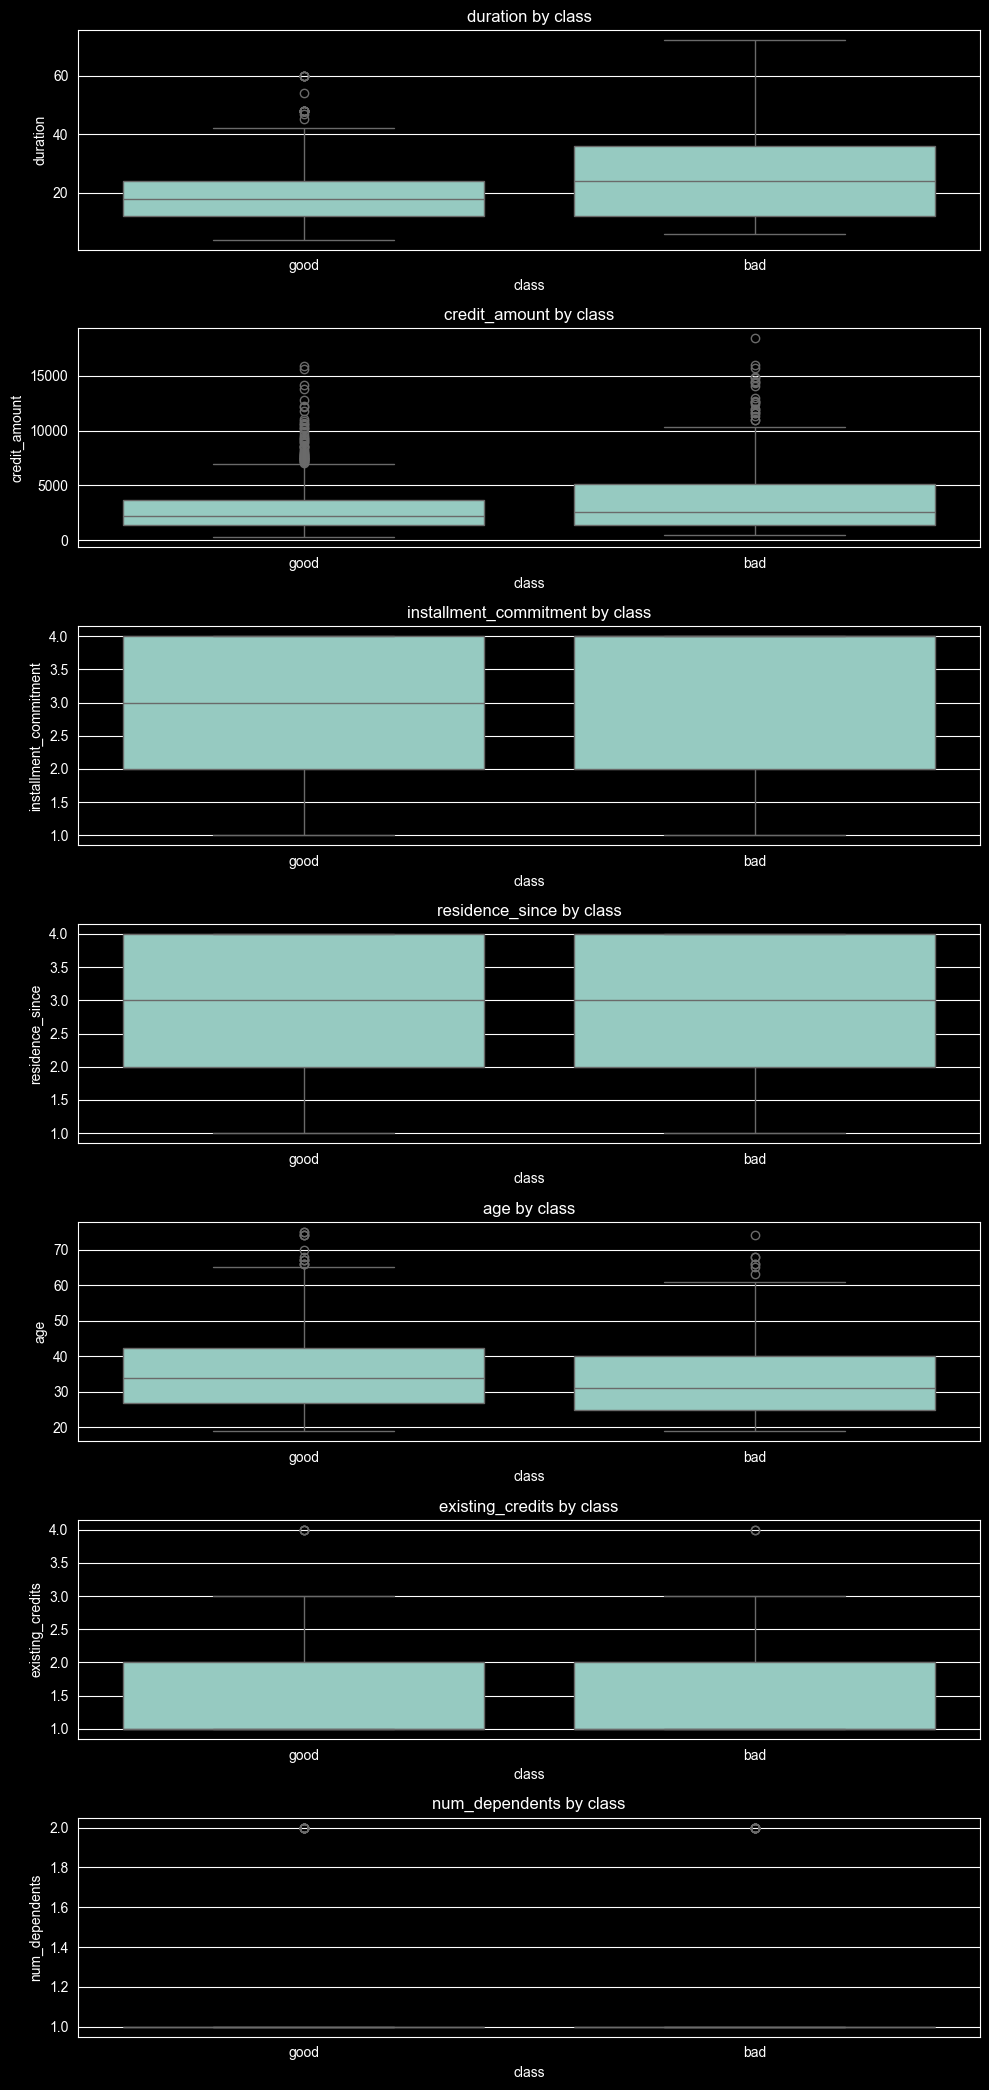

In [11]:

# Boxplots by target for numeric features
fig, axes = plt.subplots(len(num_cols), 1, figsize=(10, 3 * len(num_cols)))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x='class', y=col, ax=ax)
    ax.set_title(f'{col} by class')
plt.tight_layout()
plt.show()


In [12]:

# Top category frequencies
for col in cat_cols:
    print(f'\n===== {col} =====')
    display(df[col].value_counts(dropna=False).to_frame('count'))



===== checking_status =====


,count
checking_status,
no checking,394
<0,274
0<=X<200,269
>=200,63



===== credit_history =====


,count
credit_history,
existing paid,530
critical/other existing credit,293
delayed previously,88
all paid,49
no credits/all paid,40



===== purpose =====


...

,count
job,
skilled,630
unskilled resident,200
high qualif/self emp/mgmt,148
unemp/unskilled non res,22



===== own_telephone =====


,count
own_telephone,
none,596
yes,404



===== foreign_worker =====


,count
foreign_worker,
yes,963
no,37


In [13]:

# Target rate by category: P(bad | category)
for col in cat_cols:
    summary = (
        df.groupby(col)['target']
          .agg(['count', 'mean'])
          .rename(columns={'mean': 'bad_rate'})
          .sort_values(['bad_rate', 'count'], ascending=[False, False])
    )
    print(f'\n===== Target rate by {col} =====')
    display(summary)



===== Target rate by checking_status =====


,count,bad_rate
checking_status,,
<0,274,0.492701
0<=X<200,269,0.390335
>=200,63,0.222222
no checking,394,0.116751



===== Target rate by credit_history =====


,count,bad_rate
credit_history,,
no credits/all paid,40,0.625000
all paid,49,0.571429
existing paid,530,0.318868
delayed previously,88,0.318182
critical/other existing credit,293,0.170648



===== Target rate by purpose =====


...

,count,bad_rate
job,,
high qualif/self emp/mgmt,148,0.344595
unemp/unskilled non res,22,0.318182
skilled,630,0.295238
unskilled resident,200,0.280000



===== Target rate by own_telephone =====


,count,bad_rate
own_telephone,,
none,596,0.313758
yes,404,0.279703



===== Target rate by foreign_worker =====


,count,bad_rate
foreign_worker,,
yes,963,0.307373
no,37,0.108108


In [14]:
X = df.drop(columns=['class', 'target'])
y = df['target']


X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# second: val vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print('Train shape:', X_train.shape, y_train.shape)
print('Val shape:  ', X_val.shape, y_val.shape)
print('Test shape: ', X_test.shape, y_test.shape)

print('Train target ratio:', y_train.mean().round(3))
print('Val target ratio:  ', y_val.mean().round(3))
print('Test target ratio: ', y_test.mean().round(3))

Train shape: (700, 20) (700,)
Val shape:   (150, 20) (150,)
Test shape:  (150, 20) (150,)
Train target ratio: 0.3
Val target ratio:   0.3
Test target ratio:  0.3


**Poznamka:** Data delime na train, validation a test so stratifikaciou, aby zostal zachovany pomer tried v kazdej casti. Validation sluzi na vyber najlepsieho modelu a thresholdu, test sa ma pouzit az na finalne zhodnotenie.


In [15]:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train).astype(np.float32)
X_val_processed = preprocessor.transform(X_val).astype(np.float32)
X_test_processed = preprocessor.transform(X_test).astype(np.float32)

print('Processed train shape:', X_train_processed.shape)
print('Processed val shape:  ', X_val_processed.shape)
print('Processed test shape: ', X_test_processed.shape)


Processed train shape: (700, 61)
Processed val shape:   (150, 61)
Processed test shape:  (150, 61)


**Poznamka:** Tu pripravujeme vstup pre neuronovu siet. Numericke premennne standardizujeme a kategoricke kodujeme cez one-hot encoding, aby ich model vedel spracovat v jednotnej numerickej podobe.


In [16]:

def make_loader(X_array, y_series, batch_size=64, shuffle=False):
    X_tensor = torch.tensor(X_array, dtype=torch.float32)
    y_tensor = torch.tensor(y_series.to_numpy().reshape(-1, 1), dtype=torch.float32)
    dataset = TensorDataset(X_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [17]:

train_loader = make_loader(X_train_processed, y_train, batch_size=config["batch_size_train"], shuffle=True)
val_loader = make_loader(X_val_processed, y_val, batch_size=config["batch_size_test"], shuffle=False)
test_loader = make_loader(X_test_processed, y_test, batch_size=config["batch_size_test"], shuffle=False)


In [18]:

def predict_probabilities(model, loader, criterion=None):
    model.eval()
    all_probs, all_targets = [], []
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            probs = torch.sigmoid(logits)

            if criterion is not None:
                loss = criterion(logits, yb)
                total_loss += loss.item() * len(xb)
                total_samples += len(xb)

            all_probs.append(probs.cpu().numpy())
            all_targets.append(yb.cpu().numpy())

    probs = np.vstack(all_probs).ravel()
    targets = np.vstack(all_targets).ravel().astype(int)
    avg_loss = total_loss / total_samples if total_samples > 0 else None
    return probs, targets, avg_loss

In [19]:
def compute_metrics(y_true, y_prob, threshold=None):
    threshold = config['threshold'] if threshold is None else threshold
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics = {
        'threshold': float(threshold),
        'recall_bad': recall_score(y_true, y_pred, zero_division=0),
        'pr_auc': average_precision_score(y_true, y_prob),
        'cost_total': int(fp * 1 + fn * 5),
        'cost_per_sample': (fp * 1 + fn * 5) / len(y_true),
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
    }
    return metrics


def find_best_threshold(y_true, y_prob, thresholds=None):
    thresholds = thresholds if thresholds is not None else np.arange(0.05, 1.00, 0.05)
    best_metrics = None

    for threshold in thresholds:
        metrics = compute_metrics(y_true, y_prob, threshold=float(threshold))
        is_better = (
            best_metrics is None
            or metrics['cost_total'] < best_metrics['cost_total']
            or (
                metrics['cost_total'] == best_metrics['cost_total']
                and metrics['recall_bad'] > best_metrics['recall_bad']
            )
        )
        if is_better:
            best_metrics = metrics

    return best_metrics


**Poznamka:** `compute_metrics` pocita hlavne hodnotiace metriky pre zvoleny threshold. `find_best_threshold` prehlada viac prahov a vyberie ten, ktory minimalizuje nasu cost funkciu `FP * 1 + FN * 5`, teda uprednostni neprehliadnutie rizikoveho klienta.


In [20]:
class MLPBlock(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, dropout_rate: float, use_batch_norm: bool, use_skip_connection: bool):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
        self.batch_norm = nn.BatchNorm1d(out_dim) if use_batch_norm else None
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate) if dropout_rate > 0 else None
        self.use_skip_connection = use_skip_connection
        self.projection = nn.Identity() if in_dim == out_dim else nn.Linear(in_dim, out_dim, bias=False)

    def forward(self, x):
        out = self.linear(x)
        if self.batch_norm is not None:
            out = self.batch_norm(out)
        if self.use_skip_connection:
            out = out + self.projection(x)
        out = self.activation(out)
        if self.dropout is not None:
            out = self.dropout(out)
        return out


class CreditMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(128, 64), dropout_rate: float = 0.0, use_batch_norm: bool = False, use_skip_connection: bool = False):
        super().__init__()
        blocks = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            blocks.append(
                MLPBlock(
                    prev_dim,
                    hidden_dim,
                    dropout_rate=dropout_rate,
                    use_batch_norm=use_batch_norm,
                    use_skip_connection=use_skip_connection,
                )
            )
            prev_dim = hidden_dim
        self.feature_extractor = nn.Sequential(*blocks)
        self.output_layer = nn.Linear(prev_dim, 1)

    def forward(self, x):
        x = self.feature_extractor(x)
        return self.output_layer(x)


class BinaryFocalLossWithLogits(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight
        self.reduction = reduction

    def forward(self, logits, targets):
        bce_loss = nn.functional.binary_cross_entropy_with_logits(
            logits,
            targets,
            pos_weight=self.pos_weight,
            reduction='none',
        )
        probs = torch.sigmoid(logits)
        pt = probs * targets + (1 - probs) * (1 - targets)
        focal_factor = (1 - pt).pow(self.gamma)
        loss = focal_factor * bce_loss

        if self.reduction == 'mean':
            return loss.mean()
        if self.reduction == 'sum':
            return loss.sum()
        return loss


model = CreditMLP(
    input_dim=X_train_processed.shape[1],
    hidden_dims=tuple(config['hidden_dims']),
    dropout_rate=float(config['dropout_rate']),
    use_batch_norm=bool(config['use_batch_norm']),
    use_skip_connection=bool(config['use_skip_connection']),
).to(device)

num_neg = int((y_train == 0).sum())
num_pos = int((y_train == 1).sum())
pos_weight_value = num_neg / num_pos
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)

if config['loss_type'] == 'focal':
    criterion = BinaryFocalLossWithLogits(
        gamma=float(config['focal_gamma']),
        pos_weight=pos_weight,
    )
else:
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config['learning_rate'],
    weight_decay=config['weight_decay'],
)

print('pos_weight:', pos_weight_value)
print('dropout_rate:', config['dropout_rate'])
print('use_batch_norm:', config['use_batch_norm'])
print('use_skip_connection:', config['use_skip_connection'])
print('loss_type:', config['loss_type'])
print(model)


pos_weight: 2.3333333333333335
dropout_rate: 0.0
use_batch_norm: False
use_skip_connection: False
loss_type: bce
CreditMLP(
  (feature_extractor): Sequential(
    (0): MLPBlock(
      (linear): Linear(in_features=61, out_features=128, bias=True)
      (activation): ReLU()
      (projection): Linear(in_features=61, out_features=128, bias=False)
    )
    (1): MLPBlock(
      (linear): Linear(in_features=128, out_features=64, bias=True)
      (activation): ReLU()
      (projection): Linear(in_features=128, out_features=64, bias=False)
    )
  )
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)


**Poznamka:** MLP uz podporuje viac improvement techniques. `dropout_rate` regularizuje model proti overfittingu, `use_batch_norm` stabilizuje aktivacie medzi vrstvami, `use_skip_connection` pridava residual prepojenie medzi vstupom a vystupom bloku a `loss_type` prepina medzi weighted BCE a focal loss. Sweep potom vie otestovat aj kombinacie, kde sa niektora technika nepouzije.


In [21]:
os.environ["WANDB__SERVICE_WAIT"] = "300"
os.environ["WANDB_INIT_TIMEOUT"] = "300"

def load_env_file(env_path='.env'):
    env_values = {}
    env_file = Path(env_path)
    if not env_file.exists():
        return env_values

    for line in env_file.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        key, value = line.split('=', 1)
        env_values[key.strip()] = value.strip().strip('"').strip("'")
    return env_values

env_values = load_env_file()
wandb_api_key = (
    os.getenv('WANDB_API_KEY')
    or os.getenv('wandb_api')
    or env_values.get('WANDB_API_KEY')
    or env_values.get('wandb_api')
)

if wandb_api_key:
    os.environ['WANDB_API_KEY'] = wandb_api_key
    wandb.login(key=wandb_api_key, relogin=True)

run_name = (
    f"{config['experiment_name']}_dropout{config['dropout_rate']}"
    f"_hdims{'-'.join(map(str, config['hidden_dims']))}"
    f"_bn{int(bool(config['use_batch_norm']))}"
    f"_skip{int(bool(config['use_skip_connection']))}"
    f"_loss{config['loss_type']}"
)

run = wandb.init(
    project="NSIETE_credit",
    entity="lui-vitarius-slovak-university-of-technology",
    name=run_name,
    config={
        **config,
        'input_dim': int(X_train_processed.shape[1]),
        'num_train': int(len(X_train)),
        'num_val': int(len(X_val)),
        'num_test': int(len(X_test)),
        'pos_weight': float(pos_weight_value),
        'device': str(device),
    },
    settings=wandb.Settings(init_timeout=300),
)

run_config = dict(wandb.config)
wandb.summary['run_name'] = run_name
wandb.summary['run_config'] = run_config

print('W&B run name:', run_name)
print('W&B config for this run:')
display(pd.DataFrame([run_config]))


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/romankosik/.netrc
wandb: Currently logged in as: xkosik (xkosik-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run okwndpt7
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /Users/romankosik/PycharmProjects/Neuronove_siete/wandb/run-20260323_225720-okwndpt7
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run mlp_weighted_baseline_dropout0.0_hdims128-64_bn0_skip0_lossbce
wandb: ⭐️ View project at https://wandb.ai/lui-vitarius-slovak-university-of-technology/NSIETE_credit
wandb: 🚀 View run at https://wandb.ai/lui-vitarius-slovak-universi

W&B run name: mlp_weighted_baseline_dropout0.0_hdims128-64_bn0_skip0_lossbce
W&B config for this run:


,experiment_name,batch_size_train,batch_size_test,epochs,use_early_stopping,early_stopping_patience,learning_rate,weight_decay,hidden_dims,dropout_rate,...,use_skip_connection,loss_type,focal_gamma,threshold,input_dim,num_train,num_val,num_test,pos_weight,device
0,mlp_weighted_baseline,64,256,80,False,10,0.001,0.0001,"[128, 64]",0,...,False,bce,2,0.5,61,700,150,150,2.333333,cpu


**Poznamka:** Inicializujeme `wandb` run, pomenujeme ho podla typu experimentu a logujeme konfiguraciu. To je dolezite pri porovnavani baseline a dropout experimentov, aby boli runy vo W&B prehladne oddelene.


In [22]:
history = []
best_state = None
best_val_cost = np.inf
best_val_metrics = None
best_epoch = None
epochs_without_improvement = 0
stopped_early = False

for epoch in range(1, config['epochs'] + 1):
    model.train()
    running_loss = 0.0
    running_samples = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * len(xb)
        running_samples += len(xb)

    train_loss = running_loss / running_samples

    train_prob, train_true, train_eval_loss = predict_probabilities(model, train_loader, criterion)
    val_prob, val_true, val_eval_loss = predict_probabilities(model, val_loader, criterion)

    train_metrics = compute_metrics(train_true, train_prob)
    val_metrics = compute_metrics(val_true, val_prob)

    row = {
        'epoch': epoch,
        'train_loss': train_eval_loss,
        'val_loss': val_eval_loss,
        'train_cost_per_sample': train_metrics['cost_per_sample'],
        'train_recall_bad': train_metrics['recall_bad'],
        'train_pr_auc': train_metrics['pr_auc'],
        'val_cost_per_sample': val_metrics['cost_per_sample'],
        'val_recall_bad': val_metrics['recall_bad'],
        'val_pr_auc': val_metrics['pr_auc'],
        'val_fp': val_metrics['fp'],
        'val_fn': val_metrics['fn'],
        'val_tp': val_metrics['tp'],
        'val_tn': val_metrics['tn'],
    }
    history.append(row)
    wandb.log(row)

    improved = val_metrics['cost_total'] < best_val_cost
    if improved:
        best_val_cost = val_metrics['cost_total']
        best_val_metrics = val_metrics.copy()
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
        wandb.summary['best_epoch'] = int(best_epoch)
        wandb.summary['best_val_cost_total'] = int(best_val_metrics['cost_total'])
        wandb.summary['best_val_cost_per_sample'] = float(best_val_metrics['cost_per_sample'])
        wandb.summary['best_val_recall_bad'] = float(best_val_metrics['recall_bad'])
        wandb.summary['best_val_pr_auc'] = float(best_val_metrics['pr_auc'])
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch:03d} | "
        f"train_loss={train_eval_loss:.4f} | "
        f"val_loss={val_eval_loss:.4f} | "
        f"val_cost={val_metrics['cost_total']} | "
        f"val_recall_bad={val_metrics['recall_bad']:.4f} | "
        f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
    )

    if config.get('use_early_stopping', False) and epochs_without_improvement >= config['early_stopping_patience']:
        stopped_early = True
        wandb.summary['stopped_early'] = True
        wandb.summary['stopped_epoch'] = int(epoch)
        print(f"Early stopping triggered at epoch {epoch}.")
        break

if not stopped_early:
    wandb.summary['stopped_early'] = False
    wandb.summary['stopped_epoch'] = int(best_epoch if best_epoch is not None else config['epochs'])

model.load_state_dict(best_state)

val_prob, val_true, val_loss = predict_probabilities(model, val_loader, criterion)
best_threshold_metrics = find_best_threshold(val_true, val_prob)
best_threshold = best_threshold_metrics['threshold']

wandb.summary['best_threshold'] = float(best_threshold)
wandb.summary['best_val_cost_total_tuned_threshold'] = int(best_threshold_metrics['cost_total'])
wandb.summary['best_val_cost_per_sample_tuned_threshold'] = float(best_threshold_metrics['cost_per_sample'])
wandb.summary['best_val_recall_bad_tuned_threshold'] = float(best_threshold_metrics['recall_bad'])
wandb.summary['best_val_pr_auc_tuned_threshold'] = float(best_threshold_metrics['pr_auc'])

history_df = pd.DataFrame(history)
display(history_df.tail())
print('Best validation metrics:', best_val_metrics)
print('Best threshold on validation:', round(best_threshold, 3))
print('Validation metrics at tuned threshold:', best_threshold_metrics)


Epoch 001 | train_loss=0.9448 | val_loss=0.9506 | val_cost=88 | val_recall_bad=0.8000 | val_pr_auc=0.4962 | 
Epoch 002 | train_loss=0.9058 | val_loss=0.9187 | val_cost=89 | val_recall_bad=0.8222 | val_pr_auc=0.5359 | 
Epoch 003 | train_loss=0.8485 | val_loss=0.8716 | val_cost=109 | val_recall_bad=0.6667 | val_pr_auc=0.5868 | 
Epoch 004 | train_loss=0.7782 | val_loss=0.8165 | val_cost=99 | val_recall_bad=0.7333 | val_pr_auc=0.6160 | 
Epoch 005 | train_loss=0.7230 | val_loss=0.7738 | val_cost=102 | val_recall_bad=0.6889 | val_pr_auc=0.6421 | 
Epoch 006 | train_loss=0.6909 | val_loss=0.7588 | val_cost=84 | val_recall_bad=0.7778 | val_pr_auc=0.6512 | 
Epoch 007 | train_loss=0.6694 | val_loss=0.7594 | val_cost=85 | val_recall_bad=0.7778 | val_pr_auc=0.6481 | 
Epoch 008 | train_loss=0.6523 | val_loss=0.7671 | val_cost=94 | val_recall_bad=0.7111 | val_pr_auc=0.6391 | 
Epoch 009 | train_loss=0.6300 | val_loss=0.7709 | val_cost=100 | val_recall_bad=0.7111 | val_pr_auc=0.6314 | 
Epoch 010 | trai

,epoch,train_loss,val_loss,train_cost_per_sample,train_recall_bad,train_pr_auc,val_cost_per_sample,val_recall_bad,val_pr_auc,val_fp,val_fn,val_tp,val_tn
75,76,0.005336,2.385749,0.0,1.0,1.0,0.726667,0.622222,0.556760,24,17,28,81
76,77,0.005157,2.410312,0.0,1.0,1.0,0.753333,0.600000,0.556337,23,18,27,82
77,78,0.004973,2.423453,0.0,1.0,1.0,0.753333,0.600000,0.558240,23,18,27,82
78,79,0.004795,2.429194,0.0,1.0,1.0,0.760000,0.600000,0.557936,24,18,27,81
79,80,0.004628,2.440763,0.0,1.0,1.0,0.753333,0.600000,0.545632,23,18,27,82


Best validation metrics: {'threshold': 0.5, 'recall_bad': 0.7777777777777778, 'pr_auc': 0.6512313664170503, 'cost_total': 84, 'cost_per_sample': np.float64(0.56), 'tn': 71, 'fp': 34, 'fn': 10, 'tp': 35}
Best threshold on validation: 0.45
Validation metrics at tuned threshold: {'threshold': 0.45, 'recall_bad': 0.8444444444444444, 'pr_auc': 0.6512313664170503, 'cost_total': 74, 'cost_per_sample': np.float64(0.49333333333333335), 'tn': 66, 'fp': 39, 'fn': 7, 'tp': 38}


**Poznamka:** Tu prebieha samotny trening. Po kazdej epoche model vyhodnotime na validation sade, logujeme metriky do `wandb` a ulozime checkpoint s najlepsim validation cost. V baseline a prvych manualnych experimentoch nechavame trening bez `early stopping`, aby boli porovnania medzi jednotlivymi technikami co najcistejsie. `Early stopping` zavadzame az vo finalnom Stage 1 sweepe, kde uz doladujeme sirsi priestor hyperparametrov. Po treningu na najlepsom modeli doladime threshold na validation sade.


In [23]:
test_prob, test_true, test_loss = predict_probabilities(model, test_loader, criterion)
test_metrics = compute_metrics(test_true, test_prob)
test_metrics_tuned = compute_metrics(test_true, test_prob, threshold=best_threshold)

print('Test loss:', round(test_loss, 4))
print('Test metrics at default threshold:')
for k in ['threshold', 'cost_per_sample', 'recall_bad', 'pr_auc', 'fp', 'fn', 'tp', 'tn']:
    v = test_metrics[k]
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')

print('Test metrics at tuned threshold:')
for k in ['threshold', 'cost_per_sample', 'recall_bad', 'pr_auc', 'fp', 'fn', 'tp', 'tn']:
    v = test_metrics_tuned[k]
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')

wandb.summary.update({
    'test_loss': float(test_loss),
    'test_cost_total': int(test_metrics['cost_total']),
    'test_cost_per_sample': float(test_metrics['cost_per_sample']),
    'test_recall_bad': float(test_metrics['recall_bad']),
    'test_pr_auc': float(test_metrics['pr_auc']),
    'test_fp': int(test_metrics['fp']),
    'test_fn': int(test_metrics['fn']),
    'test_tp': int(test_metrics['tp']),
    'test_tn': int(test_metrics['tn']),
    'test_cost_total_tuned_threshold': int(test_metrics_tuned['cost_total']),
    'test_cost_per_sample_tuned_threshold': float(test_metrics_tuned['cost_per_sample']),
    'test_recall_bad_tuned_threshold': float(test_metrics_tuned['recall_bad']),
    'test_pr_auc_tuned_threshold': float(test_metrics_tuned['pr_auc']),
    'test_fp_tuned_threshold': int(test_metrics_tuned['fp']),
    'test_fn_tuned_threshold': int(test_metrics_tuned['fn']),
    'test_tp_tuned_threshold': int(test_metrics_tuned['tp']),
    'test_tn_tuned_threshold': int(test_metrics_tuned['tn']),
    'pos_weight': float(pos_weight_value),
})


Test loss: 0.7249
Test metrics at default threshold:
  threshold: 0.5000
  cost_per_sample: 0.4867
  recall_bad: 0.8000
  pr_auc: 0.6990
  fp: 28
  fn: 9
  tp: 36
  tn: 77
Test metrics at tuned threshold:
  threshold: 0.4500
  cost_per_sample: 0.4800
  recall_bad: 0.8222
  pr_auc: 0.6990
  fp: 32
  fn: 8
  tp: 37
  tn: 73


**Poznamka:** Finalny model testujeme dvoma sposobmi: s default thresholdom `0.5` a s tuned thresholdom vybranym na validation sade. Tak vidime, ci samotna zmena rozhodovacieho prahu zlepsila business metriky bez zmeny vah modelu.


,pred_good(0),pred_bad(1)
actual_good(0),73,32
actual_bad(1),8,37


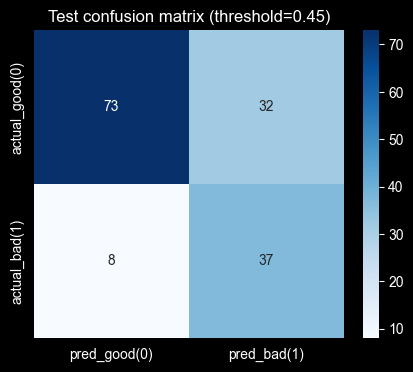

In [24]:
# Confusion matrix at tuned threshold
cm = confusion_matrix(test_true, (test_prob >= best_threshold).astype(int), labels=[0, 1])
cm_df = pd.DataFrame(cm, index=['actual_good(0)', 'actual_bad(1)'], columns=['pred_good(0)', 'pred_bad(1)'])
display(cm_df)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title(f'Test confusion matrix (threshold={best_threshold:.2f})')
wandb.log({
    'test_confusion_matrix': wandb.plot.confusion_matrix(
        probs=None,
        y_true=test_true,
        preds=(test_prob >= best_threshold).astype(int),
        class_names=['good', 'bad'],
    ),
    'test_confusion_matrix_heatmap': wandb.Image(plt.gcf()),
})
plt.show()


**Poznamka:** Confusion matrix ukazuje, kolko klientov model zaradil spravne a kolko spravil chyb typu `FP` a `FN`. Pre nas je najkritickejsi `FN`, teda rizikovy klient oznaceny ako bezpecny.


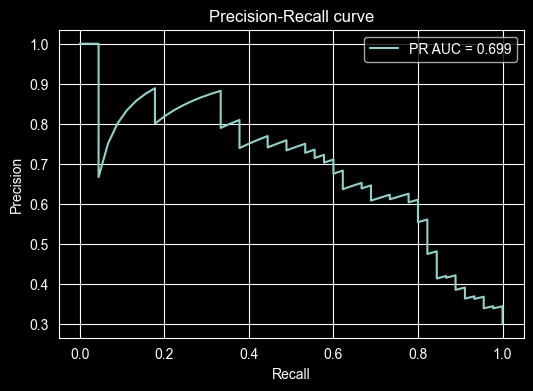

In [25]:
precision, recall, _ = precision_recall_curve(test_true, test_prob)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f'PR AUC = {test_metrics["pr_auc"]:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve')
plt.legend()
wandb.log({'test_pr_curve': wandb.Image(plt.gcf())})
plt.show()


**Poznamka:** Precision-Recall krivka ukazuje kompromis medzi precision a recall pre rozne thresholdy. Pri nevyvazenych datach je `PR AUC` informativnejsia metrika ako samotna accuracy.


In [26]:
artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(exist_ok=True)

model_path = artifacts_dir / 'credit_mlp_best.pt'
history_path = artifacts_dir / 'training_history.csv'
metadata_path = artifacts_dir / 'experiment_metadata.json'

torch.save(model.state_dict(), model_path)
history_df.to_csv(history_path, index=False)

metadata = {
    'run_config': config,
    'best_epoch': int(best_epoch) if best_epoch is not None else None,
    'best_threshold': float(best_threshold),
    'best_val_metrics': {
        k: float(v) if isinstance(v, (np.floating, float)) else int(v)
        for k, v in best_val_metrics.items()
    } if best_val_metrics is not None else None,
    'best_val_metrics_tuned_threshold': {
        k: float(v) if isinstance(v, (np.floating, float)) else int(v)
        for k, v in best_threshold_metrics.items()
    },
    'pos_weight': float(pos_weight_value),
    'input_dim': int(X_train_processed.shape[1]),
    'num_train': int(len(X_train)),
    'num_val': int(len(X_val)),
    'num_test': int(len(X_test)),
    'test_metrics': {
        k: float(v) if isinstance(v, (np.floating, float)) else int(v)
        for k, v in test_metrics.items()
    },
    'test_metrics_tuned_threshold': {
        k: float(v) if isinstance(v, (np.floating, float)) else int(v)
        for k, v in test_metrics_tuned.items()
    },
}

with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

artifact = wandb.Artifact('credit-mlp-run', type='experiment')
artifact.add_file(str(model_path))
artifact.add_file(str(history_path))
artifact.add_file(str(metadata_path))
wandb.log_artifact(artifact)
wandb.finish()

print('Saved:')
print(' -', model_path)
print(' -', history_path)
print(' -', metadata_path)


wandb: updating run metadata; uploading artifact run-okwndpt7-test_confusion_matrix_table; uploading artifact credit-mlp-run
wandb: uploading artifact run-okwndpt7-test_confusion_matrix_table; uploading artifact credit-mlp-run
wandb: uploading artifact credit-mlp-run; uploading media/images/test_pr_curve_81_18df68f077fa40e41aec.png; uploading wandb-summary.json; uploading config.yaml; uploading wandb-metadata.json (+ 3 more)
wandb: uploading history steps 0-81, summary
wandb: 
wandb: Run history:
wandb:                 epoch ▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇██
wandb: train_cost_per_sample █▇█▇▇▆▅▅▄▄▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:            train_loss █▇▆▆▅▅▅▅▄▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:          train_pr_auc ▁▂▂▂▃▄▄▅▅▆▆▇▇▇██████████████████████████
wandb:      train_recall_bad ▁▃▂▁▃▂▃▄▅▅▅▅▅▇▇█████████████████████████
wandb:   val_cost_per_sample ▁▄▁▃▅▂▃▆▅▅▇▅█▅▄▇▅▅▆█▅▆▇▅▅▆▆█▅▆▅▅▇▅▅▅▅▇▅▅
wandb:                val_fn ▁▄▃▂▂▃▅▃▃▅▅▅▆█▆▅▇▆▆▆▅▅▆▅▇▆▅▅▇▅▅▅▅▅▆▆▅▆▆▆
wandb:  

Saved:
 - artifacts/credit_mlp_best.pt
 - artifacts/training_history.csv
 - artifacts/experiment_metadata.json


**Poznamka:** Na konci ukladame model, historiu treningu a metadata experimentu. Tie iste vystupy logujeme aj ako `wandb` artifact, aby bol experiment reprodukovatelny a porovnatelny s dalsimi runmi.


## Druha Cast: Experiments And Tuning

Tato sekcia nadvazuje na baseline MLP experiment vyssie. Najprv robime samostatne cielene experimenty s jednotlivymi technikami a potom na konci spustime sirsi notebook search nad najperspektivnejsou vetvou modelu.


**Experiment Plan:** Najprv budeme testovat jednotlive improvement techniques na fixnom baseline nastaveni, aby bolo jasne, co skutocne pomaha. Az potom prejdememe na sirsi notebook random search, ktory bude ladit len tie parametre, ktore po tychto experimentoch este davaju zmysel.

**Ako citat tieto prepinače:**
- `dropout_rate = 0.0` znamena, ze dropout sa nepouzije.
- `use_batch_norm = False` znamena, ze batch normalization sa nepouzije.
- `use_skip_connection = False` znamena, ze skip connection sa nepouzije.
- `loss_type = 'bce'` znamena standardnu weighted BCE loss.
- `loss_type = 'focal'` znamena focal loss, ktora viac zdoraznuje tazke a zle klasifikovane pripady.


In [27]:

def build_run_name(run_config):
    name = (
        f"{run_config['experiment_name']}_dropout{run_config['dropout_rate']}"
        f"_hdims{'-'.join(map(str, run_config['hidden_dims']))}"
        f"_bn{int(bool(run_config['use_batch_norm']))}"
        f"_skip{int(bool(run_config['use_skip_connection']))}"
        f"_loss{run_config['loss_type']}"
        f"_es{int(bool(run_config.get('use_early_stopping', False)))}"
        f"_lr{run_config['learning_rate']}"
        f"_wd{run_config['weight_decay']}"
    )
    if run_config.get('use_early_stopping', False):
        name += f"_pat{run_config['early_stopping_patience']}"
    return name


def run_mlp_experiment(exp_overrides=None, show_plots=False):
    run_config = {**config, **(exp_overrides or {})}
    run_name = build_run_name(run_config)

    train_loader_local = make_loader(
        X_train_processed, y_train, batch_size=run_config['batch_size_train'], shuffle=True
    )
    val_loader_local = make_loader(
        X_val_processed, y_val, batch_size=run_config['batch_size_test'], shuffle=False
    )
    test_loader_local = make_loader(
        X_test_processed, y_test, batch_size=run_config['batch_size_test'], shuffle=False
    )

    num_neg = int((y_train == 0).sum())
    num_pos = int((y_train == 1).sum())
    pos_weight_value_local = num_neg / num_pos
    pos_weight_tensor = torch.tensor([pos_weight_value_local], dtype=torch.float32, device=device)

    model_local = CreditMLP(
        input_dim=X_train_processed.shape[1],
        hidden_dims=tuple(run_config['hidden_dims']),
        dropout_rate=float(run_config['dropout_rate']),
        use_batch_norm=bool(run_config['use_batch_norm']),
        use_skip_connection=bool(run_config['use_skip_connection']),
    ).to(device)

    if run_config['loss_type'] == 'focal':
        criterion_local = BinaryFocalLossWithLogits(
            gamma=float(run_config['focal_gamma']),
            pos_weight=pos_weight_tensor,
        )
    else:
        criterion_local = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

    optimizer_local = torch.optim.AdamW(
        model_local.parameters(),
        lr=run_config['learning_rate'],
        weight_decay=run_config['weight_decay'],
    )

    wandb.init(
        project='NSIETE_credit',
        entity='lui-vitarius-slovak-university-of-technology',
        name=run_name,
        config={
            **run_config,
            'input_dim': int(X_train_processed.shape[1]),
            'num_train': int(len(X_train)),
            'num_val': int(len(X_val)),
            'num_test': int(len(X_test)),
            'pos_weight': float(pos_weight_value_local),
            'device': str(device),
        },
        settings=wandb.Settings(init_timeout=300),
        reinit=True,
    )

    wandb.summary['run_name'] = run_name

    history = []
    best_state = None
    best_val_cost = np.inf
    best_val_metrics = None
    best_epoch = None
    epochs_without_improvement = 0
    stopped_early = False

    for epoch in range(1, run_config['epochs'] + 1):
        model_local.train()
        for xb, yb in train_loader_local:
            xb, yb = xb.to(device), yb.to(device)
            optimizer_local.zero_grad()
            logits = model_local(xb)
            loss = criterion_local(logits, yb)
            loss.backward()
            optimizer_local.step()

        train_prob, train_true, train_eval_loss = predict_probabilities(model_local, train_loader_local, criterion_local)
        val_prob, val_true, val_eval_loss = predict_probabilities(model_local, val_loader_local, criterion_local)

        train_metrics = compute_metrics(train_true, train_prob)
        val_metrics = compute_metrics(val_true, val_prob)

        row = {
            'epoch': epoch,
            'train_loss': train_eval_loss,
            'val_loss': val_eval_loss,
            'train_cost_per_sample': train_metrics['cost_per_sample'],
            'train_recall_bad': train_metrics['recall_bad'],
            'train_pr_auc': train_metrics['pr_auc'],
            'val_cost_per_sample': val_metrics['cost_per_sample'],
            'val_recall_bad': val_metrics['recall_bad'],
            'val_pr_auc': val_metrics['pr_auc'],
            'val_fp': val_metrics['fp'],
            'val_fn': val_metrics['fn'],
            'val_tp': val_metrics['tp'],
            'val_tn': val_metrics['tn'],
        }
        history.append(row)
        wandb.log(row)

        improved = val_metrics['cost_total'] < best_val_cost
        if improved:
            best_val_cost = val_metrics['cost_total']
            best_val_metrics = val_metrics.copy()
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model_local.state_dict().items()}
            epochs_without_improvement = 0
            wandb.summary['best_epoch'] = int(best_epoch)
            wandb.summary['best_val_cost_total'] = int(best_val_metrics['cost_total'])
            wandb.summary['best_val_cost_per_sample'] = float(best_val_metrics['cost_per_sample'])
            wandb.summary['best_val_recall_bad'] = float(best_val_metrics['recall_bad'])
            wandb.summary['best_val_pr_auc'] = float(best_val_metrics['pr_auc'])
        else:
            epochs_without_improvement += 1

        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_eval_loss:.4f} | "
            f"val_loss={val_eval_loss:.4f} | "
            f"val_cost={val_metrics['cost_total']} | "
            f"val_recall_bad={val_metrics['recall_bad']:.4f} | "
            f"val_pr_auc={val_metrics['pr_auc']:.4f} | "
        )

        if run_config.get('use_early_stopping', False) and epochs_without_improvement >= run_config['early_stopping_patience']:
            stopped_early = True
            wandb.summary['stopped_early'] = True
            wandb.summary['stopped_epoch'] = int(epoch)
            print(f"Early stopping triggered at epoch {epoch}.")
            break

    if not stopped_early:
        wandb.summary['stopped_early'] = False
        wandb.summary['stopped_epoch'] = int(best_epoch if best_epoch is not None else run_config['epochs'])

    model_local.load_state_dict(best_state)

    val_prob, val_true, _ = predict_probabilities(model_local, val_loader_local, criterion_local)
    best_threshold_metrics = find_best_threshold(val_true, val_prob)
    best_threshold = best_threshold_metrics['threshold']

    wandb.summary['best_threshold'] = float(best_threshold)
    wandb.summary['best_val_cost_total_tuned_threshold'] = int(best_threshold_metrics['cost_total'])
    wandb.summary['best_val_cost_per_sample_tuned_threshold'] = float(best_threshold_metrics['cost_per_sample'])
    wandb.summary['best_val_recall_bad_tuned_threshold'] = float(best_threshold_metrics['recall_bad'])
    wandb.summary['best_val_pr_auc_tuned_threshold'] = float(best_threshold_metrics['pr_auc'])

    test_prob, test_true, test_loss = predict_probabilities(model_local, test_loader_local, criterion_local)
    test_metrics = compute_metrics(test_true, test_prob)
    test_metrics_tuned = compute_metrics(test_true, test_prob, threshold=best_threshold)

    wandb.summary.update({
        'test_loss': float(test_loss),
        'test_cost_total': int(test_metrics['cost_total']),
        'test_cost_per_sample': float(test_metrics['cost_per_sample']),
        'test_recall_bad': float(test_metrics['recall_bad']),
        'test_pr_auc': float(test_metrics['pr_auc']),
        'test_fp': int(test_metrics['fp']),
        'test_fn': int(test_metrics['fn']),
        'test_tp': int(test_metrics['tp']),
        'test_tn': int(test_metrics['tn']),
        'test_cost_total_tuned_threshold': int(test_metrics_tuned['cost_total']),
        'test_cost_per_sample_tuned_threshold': float(test_metrics_tuned['cost_per_sample']),
        'test_recall_bad_tuned_threshold': float(test_metrics_tuned['recall_bad']),
        'test_pr_auc_tuned_threshold': float(test_metrics_tuned['pr_auc']),
        'test_fp_tuned_threshold': int(test_metrics_tuned['fp']),
        'test_fn_tuned_threshold': int(test_metrics_tuned['fn']),
        'test_tp_tuned_threshold': int(test_metrics_tuned['tp']),
        'test_tn_tuned_threshold': int(test_metrics_tuned['tn']),
        'pos_weight': float(pos_weight_value_local),
    })

    wandb.log({
        'test_confusion_matrix': wandb.plot.confusion_matrix(
            probs=None,
            y_true=test_true,
            preds=(test_prob >= best_threshold).astype(int),
            class_names=['good', 'bad'],
        ),
    })

    precision, recall, _ = precision_recall_curve(test_true, test_prob)
    plt.figure(figsize=(5, 4))
    plt.plot(recall, precision)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Test Precision-Recall curve')
    wandb.log({'pr_curve': wandb.Image(plt.gcf())})
    plt.close()

    artifacts_dir = Path('artifacts')
    artifacts_dir.mkdir(exist_ok=True)
    safe_name = run_name.replace('/', '_')
    model_path = artifacts_dir / f"{safe_name}_best.pt"
    history_path = artifacts_dir / f"{safe_name}_training_history.csv"
    metadata_path = artifacts_dir / f"{safe_name}_experiment_metadata.json"

    torch.save(model_local.state_dict(), model_path)
    pd.DataFrame(history).to_csv(history_path, index=False)
    metadata = {
        'run_config': run_config,
        'run_name': run_name,
        'best_epoch': int(best_epoch) if best_epoch is not None else None,
        'best_threshold': float(best_threshold),
        'best_val_metrics': {k: float(v) if isinstance(v, (np.floating, float)) else int(v) for k, v in best_val_metrics.items()} if best_val_metrics is not None else None,
        'best_val_metrics_tuned_threshold': {k: float(v) if isinstance(v, (np.floating, float)) else int(v) for k, v in best_threshold_metrics.items()},
        'test_metrics': {k: float(v) if isinstance(v, (np.floating, float)) else int(v) for k, v in test_metrics.items()},
        'test_metrics_tuned_threshold': {k: float(v) if isinstance(v, (np.floating, float)) else int(v) for k, v in test_metrics_tuned.items()},
    }
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)

    artifact = wandb.Artifact('credit-mlp-run', type='experiment')
    artifact.add_file(str(model_path))
    artifact.add_file(str(history_path))
    artifact.add_file(str(metadata_path))
    wandb.log_artifact(artifact)

    if show_plots:
        display(pd.DataFrame(history).tail())

    wandb.finish()

    return {
        'run_name': run_name,
        'best_epoch': int(best_epoch) if best_epoch is not None else None,
        'best_threshold': float(best_threshold),
        'best_val_cost_per_sample_tuned_threshold': float(best_threshold_metrics['cost_per_sample']),
        'test_cost_per_sample_tuned_threshold': float(test_metrics_tuned['cost_per_sample']),
        'test_recall_bad_tuned_threshold': float(test_metrics_tuned['recall_bad']),
        'test_pr_auc_tuned_threshold': float(test_metrics_tuned['pr_auc']),
    }


**Batch Dropout Experiments:** V prvej bunke definujeme zoznam behov a v druhej ich spustime postupne priamo cez notebook funkciu `run_mlp_experiment(...)`. Kazdy behov dostane vlastny `wandb` run name, takze sa daju vo W&B priamo porovnavat.


In [28]:
dropout_experiments = [
    {
        'experiment_name': 'mlp_weighted_dropout_0_0',
        'dropout_rate': 0.0,
        'use_batch_norm': False,
        'loss_type': 'bce',
        'hidden_dims': [128,64],
        'learning_rate': 1e-3,
        'weight_decay': 1e-4,
        'use_early_stopping': False,
    },
    {
        'experiment_name': 'mlp_weighted_dropout_0_2',
        'dropout_rate': 0.2,
        'use_batch_norm': False,
        'loss_type': 'bce',
        'hidden_dims': [128,64],
        'learning_rate': 1e-3,
        'weight_decay': 1e-4,
        'use_early_stopping': False,
    },
    {
        'experiment_name': 'mlp_weighted_dropout_0_4',
        'dropout_rate': 0.4,
        'use_batch_norm': False,
        'loss_type': 'bce',
        'hidden_dims': [128,64],
        'learning_rate': 1e-3,
        'weight_decay': 1e-4,
        'use_early_stopping': False,
    },
]

display(pd.DataFrame(dropout_experiments))


,experiment_name,dropout_rate,use_batch_norm,loss_type,focal_gamma,hidden_dims,learning_rate,weight_decay,use_early_stopping
0,mlp_weighted_dropout_0_0,0.0,False,bce,2.0,"[128, 64]",0.001,0.0001,False
1,mlp_weighted_dropout_0_2,0.2,False,bce,2.0,"[128, 64]",0.001,0.0001,False
2,mlp_weighted_dropout_0_4,0.4,False,bce,2.0,"[128, 64]",0.001,0.0001,False


In [29]:
dropout_experiments_results = []
for exp in dropout_experiments:
    exp_config = {**config, **exp}
    run_label = exp_config['experiment_name']
    print(f"\n=== Starting {run_label} ===")
    result = run_mlp_experiment(exp)
    dropout_experiments_results.append(result)
    print(f"=== Finished {run_label} ===")

display(pd.DataFrame(dropout_experiments_results))



=== Starting mlp_weighted_dropout_0_0 ===


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: setting up run z9j8jjox
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /Users/romankosik/PycharmProjects/Neuronove_siete/wandb/run-20260323_225728-z9j8jjox
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run mlp_weighted_dropout_0_0_dropout0.0_hdims128-64_bn0_skip0_lossbce_es0_lr0.001_wd0.0001
wandb: ⭐️ View project at https://wandb.ai/lui-vitarius-slovak-university-of-technology/NSIETE_credit
wandb: 🚀 View run at https://wandb.ai/lui-vitarius-slovak-university-of-technology/NSIETE_credit/runs/z9j8jjox


Epoch 001 | train_loss=0.9428 | val_loss=0.9490 | val_cost=119 | val_recall_bad=0.6000 | val_pr_auc=0.5067 | 
Epoch 002 | train_loss=0.9003 | val_loss=0.9141 | val_cost=90 | val_recall_bad=0.7778 | val_pr_auc=0.5355 | 
Epoch 003 | train_loss=0.8393 | val_loss=0.8651 | val_cost=89 | val_recall_bad=0.7778 | val_pr_auc=0.5614 | 
Epoch 004 | train_loss=0.7692 | val_loss=0.8156 | val_cost=98 | val_recall_bad=0.7111 | val_pr_auc=0.5892 | 
Epoch 005 | train_loss=0.7139 | val_loss=0.7835 | val_cost=95 | val_recall_bad=0.7111 | val_pr_auc=0.5906 | 
Epoch 006 | train_loss=0.6790 | val_loss=0.7798 | val_cost=89 | val_recall_bad=0.7556 | val_pr_auc=0.6144 | 
Epoch 007 | train_loss=0.6543 | val_loss=0.7815 | val_cost=106 | val_recall_bad=0.6667 | val_pr_auc=0.6185 | 
Epoch 008 | train_loss=0.6391 | val_loss=0.7871 | val_cost=93 | val_recall_bad=0.7556 | val_pr_auc=0.5932 | 
Epoch 009 | train_loss=0.6128 | val_loss=0.7902 | val_cost=107 | val_recall_bad=0.6667 | val_pr_auc=0.5850 | 
Epoch 010 | trai

wandb: updating run metadata; uploading artifact run-z9j8jjox-test_confusion_matrix_table; uploading artifact credit-mlp-run
wandb: uploading artifact run-z9j8jjox-test_confusion_matrix_table; uploading artifact credit-mlp-run
wandb: uploading artifact credit-mlp-run
wandb: uploading media/table/test_confusion_matrix_table_80_973fa29f7ae869a1c730.table.json; uploading media/images/pr_curve_81_cf1de028a8a174d41699.png; uploading wandb-summary.json; uploading config.yaml; uploading wandb-metadata.json
wandb: uploading history steps 0-81, summary
wandb: 
wandb: Run history:
wandb:                 epoch ▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇███
wandb: train_cost_per_sample █▆▆▆▅▅▄▄▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:            train_loss █▇▆▆▅▄▄▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:          train_pr_auc ▁▃▃▄▄▅▅▆▇▇▇█████████████████████████████
wandb:      train_recall_bad ▁▄▄▄▄▄▅▇████████████████████████████████
wandb:   val_cost_per_sample ▆▁▂▂▃▅▄▄▄▄▃▇▇▇▇▇▇▇█▇▇▇▇█▇▇█████████▇█▇█▇
wa

=== Finished mlp_weighted_dropout_0_0 ===

=== Starting mlp_weighted_dropout_0_2 ===


...

wandb: setting up run ukuunhjg
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /Users/romankosik/PycharmProjects/Neuronove_siete/wandb/run-20260323_225742-ukuunhjg
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run mlp_weighted_dropout_0_4_dropout0.4_hdims128-64_bn0_skip0_lossbce_es0_lr0.001_wd0.0001
wandb: ⭐️ View project at https://wandb.ai/lui-vitarius-slovak-university-of-technology/NSIETE_credit
wandb: 🚀 View run at https://wandb.ai/lui-vitarius-slovak-university-of-technology/NSIETE_credit/runs/ukuunhjg


Epoch 001 | train_loss=0.9591 | val_loss=0.9615 | val_cost=183 | val_recall_bad=0.2222 | val_pr_auc=0.4521 | 
Epoch 002 | train_loss=0.9437 | val_loss=0.9490 | val_cost=124 | val_recall_bad=0.6000 | val_pr_auc=0.5060 | 
Epoch 003 | train_loss=0.9228 | val_loss=0.9326 | val_cost=112 | val_recall_bad=0.6889 | val_pr_auc=0.5331 | 
Epoch 004 | train_loss=0.8856 | val_loss=0.9020 | val_cost=108 | val_recall_bad=0.7111 | val_pr_auc=0.5464 | 
Epoch 005 | train_loss=0.8322 | val_loss=0.8580 | val_cost=104 | val_recall_bad=0.6889 | val_pr_auc=0.5815 | 
Epoch 006 | train_loss=0.7739 | val_loss=0.8160 | val_cost=96 | val_recall_bad=0.7556 | val_pr_auc=0.5959 | 
Epoch 007 | train_loss=0.7281 | val_loss=0.7837 | val_cost=103 | val_recall_bad=0.6889 | val_pr_auc=0.6075 | 
Epoch 008 | train_loss=0.7034 | val_loss=0.7782 | val_cost=87 | val_recall_bad=0.7778 | val_pr_auc=0.6022 | 
Epoch 009 | train_loss=0.6906 | val_loss=0.7717 | val_cost=100 | val_recall_bad=0.6889 | val_pr_auc=0.6206 | 
Epoch 010 | 

wandb: updating run metadata; uploading artifact run-ukuunhjg-test_confusion_matrix_table; uploading artifact credit-mlp-run
wandb: uploading artifact run-ukuunhjg-test_confusion_matrix_table; uploading artifact credit-mlp-run
wandb: uploading artifact credit-mlp-run
wandb: uploading config.yaml; uploading wandb-metadata.json
wandb: uploading history steps 0-81, summary
wandb: 
wandb: Run history:
wandb:                 epoch ▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇██
wandb: train_cost_per_sample █▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:            train_loss ██▆▆▆▅▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
wandb:          train_pr_auc ▁▃▃▃▄▄▅▅▆▆▆▆▆▇▇▇▇▇▇█████████████████████
wandb:      train_recall_bad ▁▅▅▆▇▇▆▆▆▇▇▇▇▇▇▇████████████████████████
wandb:   val_cost_per_sample █▄▃▃▃▂▂▁▂▁▃▂▂▂▂▂▃▂▂▃▂▂▃▃▂▂▃▃▂▄▃▃▃▃▃▄▃▄▃▃
wandb:                val_fn █▂▂▂▂▂▁▂▂▁▂▂▂▃▃▂▃▃▃▂▂▂▃▂▄▂▂▃▂▃▂▃▃▃▃▄▄▃▃▃
wandb:                val_fp ▁█▆█▇▇▇▆▆▆▆▆▆▆▆▆▆▅▆▆▆▆▆▅▆▆▅▆▅▅▆▅▅▅▅▅▅▅▆▅
wandb:              val_loss ▃▂▁▁▁▁▁▁▁▁

=== Finished mlp_weighted_dropout_0_4 ===


,run_name,best_epoch,best_threshold,best_val_cost_per_sample_tuned_threshold,test_cost_per_sample_tuned_threshold,test_recall_bad_tuned_threshold,test_pr_auc_tuned_threshold
0,mlp_weighted_dropout_0_0_dropout0.0_hdims128-6...,14,0.35,0.473333,0.480000,0.866667,0.697628
1,mlp_weighted_dropout_0_2_dropout0.2_hdims128-6...,5,0.45,0.453333,0.486667,0.844444,0.714693
2,mlp_weighted_dropout_0_4_dropout0.4_hdims128-6...,10,0.20,0.506667,0.546667,0.955556,0.693858


**Zaver Dropout Experimentu:** Na zaklade porovnania samostatnych `wandb` runov vysiel najlepsie variant s `dropout_rate = 0.2`


**Batch Normalization Experiment:** Dalsi krok je otestovat, ci batch normalization pomoze stabilite treningu a generalizacii modelu. Budeme porovnavat dve verzie pri rovnakom nastaveni ako najlepsi dropout experiment: `use_batch_norm = False` a `use_batch_norm = True`, zatial co `dropout_rate = 0.2` nechame fixny.


In [30]:
batch_norm_experiments = [
    {
        'experiment_name': 'mlp_dropout_0_2_batchnorm_off',
        'dropout_rate': 0.2,
        'use_batch_norm': False,
        'loss_type': 'bce',
        'hidden_dims': [128,64],
        'learning_rate': 1e-3,
        'weight_decay': 1e-4,
        'use_early_stopping': False,
    },
    {
        'experiment_name': 'mlp_dropout_0_2_batchnorm_on',
        'dropout_rate': 0.2,
        'use_batch_norm': True,
        'loss_type': 'bce',
        'hidden_dims': [128,64],
        'learning_rate': 1e-3,
        'weight_decay': 1e-4,
        'use_early_stopping': False,
    },
]

display(pd.DataFrame(batch_norm_experiments))


,experiment_name,dropout_rate,use_batch_norm,loss_type,focal_gamma,hidden_dims,learning_rate,weight_decay,use_early_stopping
0,mlp_dropout_0_2_batchnorm_off,0.2,False,bce,2.0,"[128, 64]",0.001,0.0001,False
1,mlp_dropout_0_2_batchnorm_on,0.2,True,bce,2.0,"[128, 64]",0.001,0.0001,False


In [31]:
batch_norm_experiments_results = []
for exp in batch_norm_experiments:
    exp_config = {**config, **exp}
    run_label = exp_config['experiment_name']
    print(f"\n=== Starting {run_label} ===")
    result = run_mlp_experiment(exp)
    batch_norm_experiments_results.append(result)
    print(f"=== Finished {run_label} ===")

display(pd.DataFrame(batch_norm_experiments_results))



=== Starting mlp_dropout_0_2_batchnorm_off ===


wandb: setting up run 3i80txp4
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /Users/romankosik/PycharmProjects/Neuronove_siete/wandb/run-20260323_225749-3i80txp4
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run mlp_dropout_0_2_batchnorm_off_dropout0.2_hdims128-64_bn0_skip0_lossbce_es0_lr0.001_wd0.0001
wandb: ⭐️ View project at https://wandb.ai/lui-vitarius-slovak-university-of-technology/NSIETE_credit
wandb: 🚀 View run at https://wandb.ai/lui-vitarius-slovak-university-of-technology/NSIETE_credit/runs/3i80txp4


Epoch 001 | train_loss=0.9461 | val_loss=0.9479 | val_cost=149 | val_recall_bad=0.4444 | val_pr_auc=0.4764 | 
Epoch 002 | train_loss=0.9135 | val_loss=0.9203 | val_cost=99 | val_recall_bad=0.7111 | val_pr_auc=0.5066 | 
Epoch 003 | train_loss=0.8677 | val_loss=0.8832 | val_cost=97 | val_recall_bad=0.7111 | val_pr_auc=0.5278 | 
Epoch 004 | train_loss=0.8103 | val_loss=0.8388 | val_cost=81 | val_recall_bad=0.8222 | val_pr_auc=0.5516 | 
Epoch 005 | train_loss=0.7512 | val_loss=0.7933 | val_cost=93 | val_recall_bad=0.7333 | val_pr_auc=0.5827 | 
Epoch 006 | train_loss=0.7112 | val_loss=0.7673 | val_cost=94 | val_recall_bad=0.7111 | val_pr_auc=0.6083 | 
Epoch 007 | train_loss=0.6863 | val_loss=0.7548 | val_cost=83 | val_recall_bad=0.7778 | val_pr_auc=0.6268 | 
Epoch 008 | train_loss=0.6678 | val_loss=0.7552 | val_cost=94 | val_recall_bad=0.7333 | val_pr_auc=0.6424 | 
Epoch 009 | train_loss=0.6525 | val_loss=0.7563 | val_cost=87 | val_recall_bad=0.7778 | val_pr_auc=0.6378 | 
Epoch 010 | train_

wandb: updating run metadata; uploading artifact run-3i80txp4-test_confusion_matrix_table; uploading artifact credit-mlp-run
wandb: uploading artifact run-3i80txp4-test_confusion_matrix_table; uploading artifact credit-mlp-run
wandb: uploading artifact credit-mlp-run
wandb: uploading history steps 0-81, summary
wandb: 
wandb: Run history:
wandb:                 epoch ▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇███
wandb: train_cost_per_sample █▇▆▆▆▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:            train_loss ██▇▆▆▆▆▆▆▅▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:          train_pr_auc ▁▂▃▃▄▄▅▅▆▆▇▇▇▇██████████████████████████
wandb:      train_recall_bad ▁▃▃▄▄▄▄▄▄▅▆▇▆▇▇▇████████████████████████
wandb:   val_cost_per_sample █▃▁▂▁▃▃▄▃▅▄▄▃▅▄▅▄▃▃▆▅▆▅▅▄▂▅▅▄▆▅▄▄▅▆▄▄▄▄▄
wandb:                val_fn █▁▃▃▂▂▃▃▃▄▃▄▄▄▄▃▅▄▆▆▅▄▆▅▆▆▆▆▆▆▆▄▇▆▆▅▅▆▅▆
wandb:                val_fp ▇▆▅█▇██▆▆▃▅▅▄▇▄▄▂▂▂▄▁▂▂▄▁▄▁▁▃▁▄▁▄▃▂▂▁▁▃▂
wandb:              val_loss ▂▂▁▁▁▁▁▁▁▁▂▂▂▂▂▃▃▄▄▄▄▅▅▅▅▅▆▆▅▆▆▆▇▇█▇▇███
wandb:            val_pr_auc 

=== Finished mlp_dropout_0_2_batchnorm_off ===

=== Starting mlp_dropout_0_2_batchnorm_on ===


wandb: setting up run juzjwcxh
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /Users/romankosik/PycharmProjects/Neuronove_siete/wandb/run-20260323_225756-juzjwcxh
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run mlp_dropout_0_2_batchnorm_on_dropout0.2_hdims128-64_bn1_skip0_lossbce_es0_lr0.001_wd0.0001
wandb: ⭐️ View project at https://wandb.ai/lui-vitarius-slovak-university-of-technology/NSIETE_credit
wandb: 🚀 View run at https://wandb.ai/lui-vitarius-slovak-university-of-technology/NSIETE_credit/runs/juzjwcxh


Epoch 001 | train_loss=0.9253 | val_loss=0.9327 | val_cost=142 | val_recall_bad=0.4667 | val_pr_auc=0.5570 | 
Epoch 002 | train_loss=0.8295 | val_loss=0.8635 | val_cost=111 | val_recall_bad=0.6667 | val_pr_auc=0.5908 | 
Epoch 003 | train_loss=0.7384 | val_loss=0.8114 | val_cost=100 | val_recall_bad=0.7333 | val_pr_auc=0.6038 | 
Epoch 004 | train_loss=0.6787 | val_loss=0.7810 | val_cost=89 | val_recall_bad=0.7778 | val_pr_auc=0.6343 | 
Epoch 005 | train_loss=0.6402 | val_loss=0.7709 | val_cost=93 | val_recall_bad=0.7556 | val_pr_auc=0.6257 | 
Epoch 006 | train_loss=0.6128 | val_loss=0.7718 | val_cost=94 | val_recall_bad=0.7556 | val_pr_auc=0.6265 | 
Epoch 007 | train_loss=0.5859 | val_loss=0.7802 | val_cost=93 | val_recall_bad=0.7556 | val_pr_auc=0.6245 | 
Epoch 008 | train_loss=0.5586 | val_loss=0.7779 | val_cost=100 | val_recall_bad=0.7111 | val_pr_auc=0.6482 | 
Epoch 009 | train_loss=0.5327 | val_loss=0.7767 | val_cost=99 | val_recall_bad=0.7111 | val_pr_auc=0.6429 | 
Epoch 010 | tra

wandb: updating run metadata; uploading artifact run-juzjwcxh-test_confusion_matrix_table; uploading artifact credit-mlp-run
wandb: uploading artifact run-juzjwcxh-test_confusion_matrix_table; uploading artifact credit-mlp-run
wandb: uploading artifact credit-mlp-run
wandb: uploading wandb-summary.json; uploading config.yaml; uploading wandb-metadata.json; uploading requirements.txt; uploading media/table/test_confusion_matrix_table_80_b28749b01f7d8371943e.table.json (+ 1 more)
wandb: uploading history steps 0-81, summary
wandb: 
wandb: Run history:
wandb:                 epoch ▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇███
wandb: train_cost_per_sample █▅▅▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:            train_loss █▇▇▆▅▄▄▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:          train_pr_auc ▁▂▄▅▅▆▆▇▇▇██████████████████████████████
wandb:      train_recall_bad ▁▃▃▄▄▅▆▆▇███████████████████████████████
wandb:   val_cost_per_sample ▅▁▂▂▃▃▂▂▂▁▃▁▄▃▃▅▃▆▅▄▅▅▅▄▄▄▅▅▃▅▅▂█▆▅▅▆▅▆▅
wandb:                va

=== Finished mlp_dropout_0_2_batchnorm_on ===


,run_name,best_epoch,best_threshold,best_val_cost_per_sample_tuned_threshold,test_cost_per_sample_tuned_threshold,test_recall_bad_tuned_threshold,test_pr_auc_tuned_threshold
0,mlp_dropout_0_2_batchnorm_off_dropout0.2_hdims...,4,0.45,0.500000,0.486667,0.866667,0.749035
1,mlp_dropout_0_2_batchnorm_on_dropout0.2_hdims1...,4,0.30,0.493333,0.493333,0.955556,0.686802


**Zaver Batch Normalization Experimentu:** Batch normalization v tomto nastaveni nepriniesla zlepsenie. Pri porovnani s najlepsim dropout modelom (`dropout_rate = 0.2`) neviedla k nizsej hodnote `best_val_cost_per_sample_tuned_threshold`, teda validation cost per sample zostal rovnaky alebo horsi ako bez batch normalization. Z toho dovodu ju zatial nepovazujeme za prinosnu techniku pre tento dataset a tuto MLP konfiguraciu.


**Focal Loss Experiment:** Referencny model s weighted BCE loss uz mame z predchadzajuceho dropout experimentu (`dropout_rate = 0.2`, `use_batch_norm = False`). Preto teraz spustame uz len novu variantu s `focal loss` a vo W&B ju porovname s existujucim BCE runom pri rovnakom nastaveni ostatnych hyperparametrov.


In [32]:
focal_loss_experiments = [
    {
        'experiment_name': 'mlp_dropout_0_2_focal',
        'dropout_rate': 0.2,
        'use_batch_norm': False,
        'loss_type': 'focal',
        'focal_gamma': 2.0,
        'hidden_dims': [128,64],
        'learning_rate': 1e-3,
        'weight_decay': 1e-4,
        'use_early_stopping': False,
    },
]

display(pd.DataFrame(focal_loss_experiments))


,experiment_name,dropout_rate,use_batch_norm,loss_type,focal_gamma,hidden_dims,learning_rate,weight_decay,use_early_stopping
0,mlp_dropout_0_2_focal,0.2,False,focal,2.0,"[128, 64]",0.001,0.0001,False


In [33]:
focal_loss_experiments_results = []
for exp in focal_loss_experiments:
    exp_config = {**config, **exp}
    run_label = exp_config['experiment_name']
    print(f"\n=== Starting {run_label} ===")
    result = run_mlp_experiment(exp)
    focal_loss_experiments_results.append(result)
    print(f"=== Finished {run_label} ===")

display(pd.DataFrame(focal_loss_experiments_results))



=== Starting mlp_dropout_0_2_focal ===


wandb: setting up run w0bxdkuz
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /Users/romankosik/PycharmProjects/Neuronove_siete/wandb/run-20260323_225803-w0bxdkuz
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run mlp_dropout_0_2_focal_dropout0.2_hdims128-64_bn0_skip0_lossfocal_es0_lr0.001_wd0.0001
wandb: ⭐️ View project at https://wandb.ai/lui-vitarius-slovak-university-of-technology/NSIETE_credit
wandb: 🚀 View run at https://wandb.ai/lui-vitarius-slovak-university-of-technology/NSIETE_credit/runs/w0bxdkuz


Epoch 001 | train_loss=0.2334 | val_loss=0.2364 | val_cost=101 | val_recall_bad=0.7778 | val_pr_auc=0.4753 | 
Epoch 002 | train_loss=0.2205 | val_loss=0.2268 | val_cost=81 | val_recall_bad=0.8444 | val_pr_auc=0.5001 | 
Epoch 003 | train_loss=0.2049 | val_loss=0.2144 | val_cost=101 | val_recall_bad=0.7111 | val_pr_auc=0.5326 | 
Epoch 004 | train_loss=0.1895 | val_loss=0.2056 | val_cost=88 | val_recall_bad=0.8000 | val_pr_auc=0.5610 | 
Epoch 005 | train_loss=0.1783 | val_loss=0.1996 | val_cost=92 | val_recall_bad=0.7333 | val_pr_auc=0.5823 | 
Epoch 006 | train_loss=0.1711 | val_loss=0.1999 | val_cost=97 | val_recall_bad=0.7333 | val_pr_auc=0.6236 | 
Epoch 007 | train_loss=0.1655 | val_loss=0.2001 | val_cost=101 | val_recall_bad=0.7111 | val_pr_auc=0.6199 | 
Epoch 008 | train_loss=0.1615 | val_loss=0.2028 | val_cost=84 | val_recall_bad=0.8000 | val_pr_auc=0.5966 | 
Epoch 009 | train_loss=0.1565 | val_loss=0.2010 | val_cost=107 | val_recall_bad=0.6889 | val_pr_auc=0.5973 | 
Epoch 010 | tra

wandb: updating run metadata; uploading artifact run-w0bxdkuz-test_confusion_matrix_table; uploading artifact credit-mlp-run
wandb: uploading artifact run-w0bxdkuz-test_confusion_matrix_table; uploading artifact credit-mlp-run
wandb: uploading artifact credit-mlp-run
wandb: uploading wandb-metadata.json; uploading requirements.txt; uploading media/table/test_confusion_matrix_table_80_6f3ebbc04d42300174a5.table.json; uploading media/images/pr_curve_81_6908172f31afdb92cd49.png; uploading wandb-summary.json (+ 1 more)
wandb: uploading history steps 0-81, summary
wandb: 
wandb: Run history:
wandb:                 epoch ▁▁▁▁▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇██
wandb: train_cost_per_sample █▇▆▆▅▅▅▄▃▃▃▃▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:            train_loss █▆▆▆▅▅▅▄▄▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:          train_pr_auc ▁▂▄▅▅▆▇▇▇▇██████████████████████████████
wandb:      train_recall_bad ▁▂▁▃▄▄▄▄▄▇▇▇██▇█████████████████████████
wandb:   val_cost_per_sample ▄▁▄▂▃▁▃▄▄▃▄▄▅▄▄▄▆▃█▄▄▅▆▄▃▅▆

=== Finished mlp_dropout_0_2_focal ===


,run_name,best_epoch,best_threshold,best_val_cost_per_sample_tuned_threshold,test_cost_per_sample_tuned_threshold,test_recall_bad_tuned_threshold,test_pr_auc_tuned_threshold
0,mlp_dropout_0_2_focal_dropout0.2_hdims128-64_b...,2,0.5,0.54,0.553333,0.777778,0.701835


**Zaver Focal Loss Experimentu:** Pri porovnani s referencnym modelom s weighted BCE loss focal loss nepriniesla zlepsenie. Naopak, `test_cost_per_sample_tuned_threshold` vysla horsie ako pri BCE variante s rovnakym nastavenim (`dropout_rate = 0.4`, `use_batch_norm = False`). Z toho dovodu v dalsich experimentoch ponechavame weighted BCE loss ako hlavnu loss funkciu.


**Skip Connection Experiment:** Dalsi krok je otestovat, ci jednoducha residual skip connection pomoze prenosu informacie medzi vrstvami. Budeme porovnavat najlepsi doterajsi model bez skip connection a ten isty model s `use_skip_connection = True`, pricom ostatne nastavenia nechame rovnake.


In [34]:

skip_connection_experiments = [
    {
        'experiment_name': 'mlp_skip_off',
        'hidden_dims': [128,64],
        'dropout_rate': 0.2,
        'use_batch_norm': False,
        'use_skip_connection': False,
        'use_early_stopping': False,
        'loss_type': 'bce',
        'learning_rate': 1e-3,
        'weight_decay': 1e-4,
    },
    {
        'experiment_name': 'mlp_skip_on',
        'hidden_dims': [128,64],
        'dropout_rate': 0.2,
        'use_batch_norm': False,
        'use_skip_connection': True,
        'use_early_stopping': False,
        'loss_type': 'bce',
        'learning_rate': 1e-3,
        'weight_decay': 1e-4,
    },
]

display(pd.DataFrame(skip_connection_experiments))


,experiment_name,hidden_dims,dropout_rate,use_batch_norm,use_skip_connection,use_early_stopping,loss_type,learning_rate,weight_decay
0,mlp_skip_off,"[128, 64]",0.2,False,False,False,bce,0.001,0.0001
1,mlp_skip_on,"[128, 64]",0.2,False,True,False,bce,0.001,0.0001


In [35]:
skip_connection_experiments_results = []
for exp in skip_connection_experiments:
    exp_config = {**config, **exp}
    run_label = exp_config['experiment_name']
    print(f"\n=== Starting {run_label} ===")
    result = run_mlp_experiment(exp)
    skip_connection_experiments_results.append(result)
    print(f"=== Finished {run_label} ===")

display(pd.DataFrame(skip_connection_experiments_results))



=== Starting mlp_skip_off ===


wandb: setting up run e2rjco5a
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /Users/romankosik/PycharmProjects/Neuronove_siete/wandb/run-20260323_225810-e2rjco5a
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run mlp_skip_off_dropout0.2_hdims128-64_bn0_skip0_lossbce_es0_lr0.001_wd0.0001
wandb: ⭐️ View project at https://wandb.ai/lui-vitarius-slovak-university-of-technology/NSIETE_credit
wandb: 🚀 View run at https://wandb.ai/lui-vitarius-slovak-university-of-technology/NSIETE_credit/runs/e2rjco5a


Epoch 001 | train_loss=0.9548 | val_loss=0.9579 | val_cost=216 | val_recall_bad=0.0444 | val_pr_auc=0.4933 | 
Epoch 002 | train_loss=0.9277 | val_loss=0.9392 | val_cost=127 | val_recall_bad=0.5556 | val_pr_auc=0.4916 | 
Epoch 003 | train_loss=0.8864 | val_loss=0.9071 | val_cost=118 | val_recall_bad=0.6444 | val_pr_auc=0.5086 | 
Epoch 004 | train_loss=0.8248 | val_loss=0.8583 | val_cost=107 | val_recall_bad=0.6667 | val_pr_auc=0.5378 | 
Epoch 005 | train_loss=0.7584 | val_loss=0.8077 | val_cost=108 | val_recall_bad=0.7111 | val_pr_auc=0.5669 | 
Epoch 006 | train_loss=0.7158 | val_loss=0.7814 | val_cost=106 | val_recall_bad=0.7111 | val_pr_auc=0.5947 | 
Epoch 007 | train_loss=0.6910 | val_loss=0.7673 | val_cost=93 | val_recall_bad=0.7333 | val_pr_auc=0.6273 | 
Epoch 008 | train_loss=0.6731 | val_loss=0.7680 | val_cost=84 | val_recall_bad=0.8000 | val_pr_auc=0.6357 | 
Epoch 009 | train_loss=0.6561 | val_loss=0.7650 | val_cost=81 | val_recall_bad=0.8000 | val_pr_auc=0.6434 | 
Epoch 010 | t

wandb: updating run metadata; uploading artifact run-e2rjco5a-test_confusion_matrix_table; uploading artifact credit-mlp-run
wandb: uploading artifact run-e2rjco5a-test_confusion_matrix_table; uploading artifact credit-mlp-run
wandb: uploading artifact credit-mlp-run
wandb: uploading history steps 0-81, summary
wandb: 
wandb: Run history:
wandb:                 epoch ▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇█
wandb: train_cost_per_sample █▄▄▄▄▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:            train_loss ██▇▆▆▆▅▅▅▅▄▄▄▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:          train_pr_auc ▁▁▂▃▃▄▅▆▆▆▇▇▇▇██████████████████████████
wandb:      train_recall_bad ▁▆▆▆▇▇▇▇▇███████████████████████████████
wandb:   val_cost_per_sample █▇▅▃▁▃▃▄▃▄▁▄▃▇▃▅▃▄▃▄▄▆▄▄▅▄▄▄▄▅▅▆▄▄▄▄▅▅▄▄
wandb:                val_fn █▂▂▂▁▁▂▂▂▁▁▂▂▃▂▁▃▃▃▂▂▂▃▂▂▂▃▃▂▂▂▂▃▂▂▃▃▂▂▂
wandb:                val_fp ▃▅█▇▆▅▆▄▆▄▆▃▄▃▄▄▃▄▆▄▄▆▃▄▄▂▃▃▂▂▁▁▄▂▃▃▁▃▃▃
wandb:              val_loss ▂▂▂▁▁▁▁▁▁▁▂▂▃▃▃▄▄▅▄▅▅▆▆▆▆▆▆▆▆▆▇▇█▇█▇████
wandb:            val_pr_auc 

=== Finished mlp_skip_off ===

=== Starting mlp_skip_on ===


wandb: setting up run w3lop518
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /Users/romankosik/PycharmProjects/Neuronove_siete/wandb/run-20260323_225817-w3lop518
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run mlp_skip_on_dropout0.2_hdims128-64_bn0_skip1_lossbce_es0_lr0.001_wd0.0001
wandb: ⭐️ View project at https://wandb.ai/lui-vitarius-slovak-university-of-technology/NSIETE_credit
wandb: 🚀 View run at https://wandb.ai/lui-vitarius-slovak-university-of-technology/NSIETE_credit/runs/w3lop518


Epoch 001 | train_loss=0.9138 | val_loss=0.9166 | val_cost=99 | val_recall_bad=0.6222 | val_pr_auc=0.6258 | 
Epoch 002 | train_loss=0.8338 | val_loss=0.8528 | val_cost=99 | val_recall_bad=0.7333 | val_pr_auc=0.6017 | 
Epoch 003 | train_loss=0.7525 | val_loss=0.7914 | val_cost=102 | val_recall_bad=0.6889 | val_pr_auc=0.6052 | 
Epoch 004 | train_loss=0.7046 | val_loss=0.7704 | val_cost=85 | val_recall_bad=0.7778 | val_pr_auc=0.6295 | 
Epoch 005 | train_loss=0.6764 | val_loss=0.7681 | val_cost=104 | val_recall_bad=0.6667 | val_pr_auc=0.6429 | 
Epoch 006 | train_loss=0.6549 | val_loss=0.7845 | val_cost=81 | val_recall_bad=0.8222 | val_pr_auc=0.6368 | 
Epoch 007 | train_loss=0.6296 | val_loss=0.7952 | val_cost=113 | val_recall_bad=0.6444 | val_pr_auc=0.6271 | 
Epoch 008 | train_loss=0.6058 | val_loss=0.8020 | val_cost=94 | val_recall_bad=0.7556 | val_pr_auc=0.6054 | 
Epoch 009 | train_loss=0.5788 | val_loss=0.8071 | val_cost=116 | val_recall_bad=0.6222 | val_pr_auc=0.6119 | 
Epoch 010 | tra

wandb: updating run metadata; uploading artifact run-w3lop518-test_confusion_matrix_table; uploading artifact credit-mlp-run
wandb: uploading artifact run-w3lop518-test_confusion_matrix_table; uploading artifact credit-mlp-run
wandb: uploading artifact credit-mlp-run
wandb: uploading wandb-summary.json; uploading config.yaml; uploading wandb-metadata.json; uploading requirements.txt; uploading media/table/test_confusion_matrix_table_80_35b7c8502f4a7611409d.table.json (+ 1 more)
wandb: 
wandb: Run history:
wandb:                 epoch ▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
wandb: train_cost_per_sample ██▆▇▆▅▄▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:            train_loss █▇▆▆▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:          train_pr_auc ▁▁▂▃▃▄▆▆▆▆▇█████████████████████████████
wandb:      train_recall_bad ▁▅▆▄▇▆▇█▇▆██████████████████████████████
wandb:   val_cost_per_sample ▃▃▁▄▂▁▃▅▂▅▁▅▃▄▅▇▆▄▄▄▅▆▅▅▄▄▆▅▅▅▅▆▅▅▆▅█▄▇▇
wandb:                val_fn ▅▃▂▄▁▃▅▂▅▁▁▇▄▅▅▅▆▅▆▄▅▅▅▇▆▆▅▆▅▅▇▇▅▆▆▄█▅▇▇

=== Finished mlp_skip_on ===


,run_name,best_epoch,best_threshold,best_val_cost_per_sample_tuned_threshold,test_cost_per_sample_tuned_threshold,test_recall_bad_tuned_threshold,test_pr_auc_tuned_threshold
0,mlp_skip_off_dropout0.2_hdims128-64_bn0_skip0_...,9,0.35,0.513333,0.486667,0.866667,0.688405
1,mlp_skip_on_dropout0.2_hdims128-64_bn0_skip1_l...,20,0.35,0.506667,0.493333,0.844444,0.673572


**Zaver Skip Connection Experimentu:** Jednoducha skip connection nepriniesla zlepsenie. Aj ked bol rozdiel vo `best_val_cost_per_sample_tuned_threshold` maly, na test sade vysiel model bez skip connection lepsie. Dosiahol nizsiu hodnotu `test_cost_per_sample_tuned_threshold` a zaroven lepsie hodnoty `test_recall_bad_tuned_threshold` aj `test_pr_auc_tuned_threshold`. Preto v dalsich experimentoch pokracujeme bez skip connections.


**Architecture Experiment:** Kedze dropout pomohol, ale batch normalization, focal loss ani skip connections nepriniesli dalsie zlepsenie, dalsi krok je porovnat velkost a hlbku siete. Ostatne nastavenia nechavame fixne na najlepsom doterajsom variante: `dropout_rate = 0.4`, `use_batch_norm = False`, `use_skip_connection = False`, `loss_type = 'bce'` a bez `early stopping`. Parameter `focal_gamma` tu uz nepouzivame, pretoze sme sa rozhodli pokracovat len s weighted BCE loss.


In [36]:

architecture_experiments = [
    {
        'experiment_name': 'mlp_arch_small',
        'hidden_dims': [64],
        'dropout_rate': 0.2,
        'use_batch_norm': False,
        'use_early_stopping': False,
        'loss_type': 'bce',
        'learning_rate': 1e-3,
        'weight_decay': 1e-4,
    },
    {
        'experiment_name': 'mlp_arch_medium',
        'hidden_dims': [128, 64],
        'dropout_rate': 0.2,
        'use_batch_norm': False,
        'use_early_stopping': False,
        'loss_type': 'bce',
        'learning_rate': 1e-3,
        'weight_decay': 1e-4,
    },
    {
        'experiment_name': 'mlp_arch_large',
        'hidden_dims': [256, 128, 64],
        'dropout_rate': 0.2,
        'use_batch_norm': False,
        'use_early_stopping': False,
        'loss_type': 'bce',
        'learning_rate': 1e-3,
        'weight_decay': 1e-4,
    },
]

display(pd.DataFrame(architecture_experiments))


,experiment_name,hidden_dims,dropout_rate,use_batch_norm,use_early_stopping,loss_type,learning_rate,weight_decay
0,mlp_arch_small,[64],0.2,False,False,bce,0.001,0.0001
1,mlp_arch_medium,"[128, 64]",0.2,False,False,bce,0.001,0.0001
2,mlp_arch_large,"[256, 128, 64]",0.2,False,False,bce,0.001,0.0001


In [37]:
architecture_experiments_results = []
for exp in architecture_experiments:
    exp_config = {**config, **exp}
    run_label = exp_config['experiment_name']
    print(f"\n=== Starting {run_label} ===")
    result = run_mlp_experiment(exp)
    architecture_experiments_results.append(result)
    print(f"=== Finished {run_label} ===")

display(pd.DataFrame(architecture_experiments_results))



=== Starting mlp_arch_small ===


wandb: setting up run sbm4vznc
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /Users/romankosik/PycharmProjects/Neuronove_siete/wandb/run-20260323_225823-sbm4vznc
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run mlp_arch_small_dropout0.2_hdims64_bn0_skip0_lossbce_es0_lr0.001_wd0.0001
wandb: ⭐️ View project at https://wandb.ai/lui-vitarius-slovak-university-of-technology/NSIETE_credit
wandb: 🚀 View run at https://wandb.ai/lui-vitarius-slovak-university-of-technology/NSIETE_credit/runs/sbm4vznc


Epoch 001 | train_loss=0.9422 | val_loss=0.9500 | val_cost=143 | val_recall_bad=0.4000 | val_pr_auc=0.5687 | 
Epoch 002 | train_loss=0.9159 | val_loss=0.9298 | val_cost=109 | val_recall_bad=0.6444 | val_pr_auc=0.6035 | 
Epoch 003 | train_loss=0.8884 | val_loss=0.9083 | val_cost=110 | val_recall_bad=0.6889 | val_pr_auc=0.6164 | 
Epoch 004 | train_loss=0.8594 | val_loss=0.8858 | val_cost=105 | val_recall_bad=0.7111 | val_pr_auc=0.6094 | 
Epoch 005 | train_loss=0.8299 | val_loss=0.8620 | val_cost=100 | val_recall_bad=0.7111 | val_pr_auc=0.6029 | 
Epoch 006 | train_loss=0.8008 | val_loss=0.8378 | val_cost=101 | val_recall_bad=0.6889 | val_pr_auc=0.6156 | 
Epoch 007 | train_loss=0.7757 | val_loss=0.8195 | val_cost=97 | val_recall_bad=0.7333 | val_pr_auc=0.6110 | 
Epoch 008 | train_loss=0.7547 | val_loss=0.8047 | val_cost=95 | val_recall_bad=0.7333 | val_pr_auc=0.6164 | 
Epoch 009 | train_loss=0.7377 | val_loss=0.7937 | val_cost=95 | val_recall_bad=0.7333 | val_pr_auc=0.6191 | 
Epoch 010 | t

wandb: updating run metadata; uploading artifact run-sbm4vznc-test_confusion_matrix_table; uploading artifact credit-mlp-run
wandb: uploading artifact run-sbm4vznc-test_confusion_matrix_table; uploading artifact credit-mlp-run
wandb: uploading artifact credit-mlp-run
wandb: uploading history steps 0-81, summary
wandb: 
wandb: Run history:
wandb:                 epoch ▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇█████
wandb: train_cost_per_sample █▄▄▄▄▄▄▄▃▃▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
wandb:            train_loss █▇▇▇▆▆▅▅▅▅▄▄▄▄▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁
wandb:          train_pr_auc ▁▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇██████████
wandb:      train_recall_bad ▁▆▆▆▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████████
wandb:   val_cost_per_sample █▆▄▄▁▂▁▁▃▃▅▇▅▅▆▅▆▅▅▆▃▅▅▅▅▅▅▅█▇▇▅█▅▅▅▅▅█▅
wandb:                val_fn █▃▂▂▁▁▁▁▁▂▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂
wandb:                val_fp ▁█▅▂▅▆▅▄▄▄▄▄▄▄▅▄▄▅▄▄▅▄▄▄▅▄▄▄▄▄▃▄▄▄▄▄▄▄▄▄
wandb:              val_loss ▇▇▆▅▄▂▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▇▇█
wandb:            val_pr_auc 

=== Finished mlp_arch_small ===

=== Starting mlp_arch_medium ===


...

wandb: setting up run lr8iir9y
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /Users/romankosik/PycharmProjects/Neuronove_siete/wandb/run-20260323_225837-lr8iir9y
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run mlp_arch_large_dropout0.2_hdims256-128-64_bn0_skip0_lossbce_es0_lr0.001_wd0.0001
wandb: ⭐️ View project at https://wandb.ai/lui-vitarius-slovak-university-of-technology/NSIETE_credit
wandb: 🚀 View run at https://wandb.ai/lui-vitarius-slovak-university-of-technology/NSIETE_credit/runs/lr8iir9y


Epoch 001 | train_loss=0.9504 | val_loss=0.9559 | val_cost=88 | val_recall_bad=0.9111 | val_pr_auc=0.5123 | 
Epoch 002 | train_loss=0.8906 | val_loss=0.9087 | val_cost=105 | val_recall_bad=0.7556 | val_pr_auc=0.5450 | 
Epoch 003 | train_loss=0.7836 | val_loss=0.8325 | val_cost=95 | val_recall_bad=0.7778 | val_pr_auc=0.5763 | 
Epoch 004 | train_loss=0.6994 | val_loss=0.7893 | val_cost=94 | val_recall_bad=0.7333 | val_pr_auc=0.6338 | 
Epoch 005 | train_loss=0.6656 | val_loss=0.8132 | val_cost=88 | val_recall_bad=0.7333 | val_pr_auc=0.6422 | 
Epoch 006 | train_loss=0.6472 | val_loss=0.8253 | val_cost=122 | val_recall_bad=0.5778 | val_pr_auc=0.6262 | 
Epoch 007 | train_loss=0.5994 | val_loss=0.8224 | val_cost=108 | val_recall_bad=0.6667 | val_pr_auc=0.6213 | 
Epoch 008 | train_loss=0.5778 | val_loss=0.8381 | val_cost=99 | val_recall_bad=0.7333 | val_pr_auc=0.6068 | 
Epoch 009 | train_loss=0.5286 | val_loss=0.8592 | val_cost=107 | val_recall_bad=0.6667 | val_pr_auc=0.6128 | 
Epoch 010 | tra

wandb: updating run metadata; uploading artifact run-lr8iir9y-test_confusion_matrix_table; uploading artifact credit-mlp-run
wandb: uploading artifact run-lr8iir9y-test_confusion_matrix_table; uploading artifact credit-mlp-run
wandb: uploading artifact credit-mlp-run
wandb: uploading wandb-metadata.json; uploading requirements.txt; uploading media/table/test_confusion_matrix_table_80_e4eab2ea6addbd63fe42.table.json; uploading media/images/pr_curve_81_2a07c164362f3abb20ee.png; uploading wandb-summary.json (+ 1 more)
wandb: uploading history steps 0-81, summary
wandb: 
wandb: Run history:
wandb:                 epoch ▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
wandb: train_cost_per_sample ██▅▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:            train_loss ██▇▆▆▅▅▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:          train_pr_auc ▁▁▂▃▄▆▇▇████████████████████████████████
wandb:      train_recall_bad ▃▁▄▅▅▇█▇▇███████████████████████████████
wandb:   val_cost_per_sample ▃▁▃▃▃▃▃▄▄▄▇▃▆█▅▅▇▆▄▄▄▃▄▅▃▄▃

=== Finished mlp_arch_large ===


,run_name,best_epoch,best_threshold,best_val_cost_per_sample_tuned_threshold,test_cost_per_sample_tuned_threshold,test_recall_bad_tuned_threshold,test_pr_auc_tuned_threshold
0,mlp_arch_small_dropout0.2_hdims64_bn0_skip0_lo...,12,0.25,0.513333,0.546667,0.911111,0.707885
1,mlp_arch_medium_dropout0.2_hdims128-64_bn0_ski...,4,0.50,0.540000,0.520000,0.777778,0.730365
2,mlp_arch_large_dropout0.2_hdims256-128-64_bn0_...,1,0.50,0.586667,0.626667,0.888889,0.697634


**Zaver Architecture Experimentu:** Z troch testovanych architektur `[64]`, `[128, 64]` a `[256, 128, 64]` vysla najlepsie stredna architektura `[128, 64]`. Dosiahla najnizsiu hodnotu `best_val_cost_per_sample_tuned_threshold` v ramci tejto experimentnej vetvy a zaroven si udrzala velmi dobre hodnoty `test_cost_per_sample_tuned_threshold`, `test_recall_bad_tuned_threshold` a `test_pr_auc_tuned_threshold`. Preto ju volime ako finalnu architekturu MLP modelu.


## Finalny Sweep

Na zaklade predchadzajucich manualnych experimentov fixujeme `loss_type = 'bce'`, `use_batch_norm = False` a `use_skip_connection = False`. `Early stopping` zavadzame az v tomto Stage 1 sweepe, pretoze uz nejde o izolovane porovnanie jednej techniky, ale o finalne automatizovane doladenie sirsej kombinacie hyperparametrov cez `wandb sweep` a technicky runner `train_mlp.py`.


- vybera kombinacie parametrov `hidden_dims`, `dropout_rate`, `learning_rate`, `weight_decay` a `early_stopping_patience`
- v Stage 1 sweepe uz pouzivame `early stopping`, aby sa pri vacsom pocte behov netrenovali zbytocne dlhe a preucene modely

**Search space:**
- `hidden_dims`: `[64]`, `[128, 64]`, `[128, 128, 64]`, `[256, 128, 64]`
- `dropout_rate`: `0.1`, `0.2`, `0.3`
- `learning_rate`: `0.001`, `0.0005`, `0.0003`
- `weight_decay`: `0.0001`, `0.001`
- `early_stopping_patience`: `8`, `10`, `12`


In [38]:
from pathlib import Path
print(Path('sweep_mlp_stage1.yaml').read_text())


entity: lui-vitarius-slovak-university-of-technology
project: NSIETE_credit
program: train_mlp.py
method: random
metric:
  name: best_val_cost_per_sample_tuned_threshold
  goal: minimize
parameters:
  experiment_name:
    value: mlp_stage1_sweep
  batch_size_train:
    value: 64
  batch_size_test:
    value: 256
  epochs:
    value: 80
  threshold:
    value: 0.5
  seed:
    value: 42
  loss_type:
    value: bce
  use_early_stopping:
    value: true
  use_batch_norm:
    value: false
  use_skip_connection:
    value: false
  hidden_dims:
    values:
      - [64]
      - [128, 64]
      - [128, 128, 64]
      - [256, 128, 64]
  dropout_rate:
    values: [0.1, 0.2, 0.3]
  learning_rate:
    values: [0.001, 0.0005, 0.0003]
  weight_decay:
    values: [0.0001, 0.001]
  early_stopping_patience:
    values: [8, 10, 12]



**Zaver Stage 1 Sweepu:** Po prvom sweep-e vysla najlepsie konfiguracia `mlp_stage1_sweep_dropout0.1_hdims128-64_bn0_skip0_lossbce_es1_lr0.0005_wd0.0001_pat8`. V ramci Stage 1 sweepu dosiahla najnizsiu hodnotu `best_val_cost_per_sample_tuned_threshold = 0.4733`, a teda najlepsiu validation cost spomedzi testovanych kombinacii. Ako najlepsi kandidat sa ukazal model s architekturou `[128, 64]`, `dropout_rate = 0.1`, `learning_rate = 0.0005`, `weight_decay = 0.0001`, bez batch normalization a bez skip connections. V tejto faze uz bol zapnuty aj `early stopping`, pretoze sweep sluzil na finalne doladenie kombinacie hyperparametrov, nie na izolovane porovnanie jednej techniky.


## Finalny Vybrany Model

Ako finalny model vyberame konfiguraciu `mlp_weighted_dropout_0_2_dropout0.2_hdims128-64_bn0_skip0_lossbce_es0_lr0.001_wd0.0001`. Tento model nevysiel z finalneho sweepu, ale z manualneho dropout experimentu. Dovod je jednoduchy: v spolocnom porovnani vsetkych behov dosiahol najlepsiu hodnotu `best_val_cost_per_sample_tuned_threshold = 0.4533`, teda najnizsi validation cost zo vsetkych modelov. Na test sade dosiahol `test_cost_per_sample_tuned_threshold = 0.4867`, `test_recall_bad_tuned_threshold = 0.8444` a `test_pr_auc_tuned_threshold = 0.7147`.

**Interpretacia:** Finalny Stage 1 sweep zatial manualny dropout model neprekonal. Najpravdepodobnejsie vysvetlenie je, ze sweep bezal prilis kratko a nepokryl dostatocne velku cast search space. Preto ako finalny model ponechavame najlepsiu manualne overenu konfiguraciu s `dropout_rate = 0.2`, architekturou `[128, 64]`, weighted BCE loss, bez batch normalization, bez skip connections a bez `early stopping`.
